# Exam Project: The "Cost of Quality" 
## Legislative Shocks to Child Labor and the Fertility Transition in 19th-Century Britain

**Course:** Economics-Demography  
**Student ID:** LPX972
**Methodology:** Difference-in-Differences (DiD)  
**Data Sources:** Populations Past (1851–1891), UK Data Service (1831 Baseline)

---

### **1. Introduction & Motivation**
This project investigates the impact of the **1833 and 1844 Factory Acts** on the British fertility transition. While much of the literature focuses on the late-19th-century decline, this study explores whether earlier legislative restrictions on child labor and the introduction of mandatory schooling for factory children acted as a catalyst for the "Quantity-Quality" (Q-Q) trade-off.

### **2. Theoretical Framework**
The core of this analysis rests on the **Standard Quantity-Quality Model**. According to Unified Growth Theory, the primary trigger for the demographic transition is the rise in the demand for human capital. 

The **1833 Factory Act** introduced two critical economic shocks:
1. **The Opportunity Cost Shock**: By restricting the hours children aged 9–13 could work, it reduced the economic "benefit" of high-quantity fertility.
2. **The Schooling Mandate**: It required two hours of daily elementary education for factory children, effectively raising the "price" of child quality.

I test whether these shocks led to a faster decline in the **Total Fertility Rate (TFR)** in textile-heavy districts compared to agricultural controls.

### **3. Data and Variables**
The primary dataset is a Registration District (RD) level panel derived from **Populations Past**.

**Core Variables:**
* **`TFR` (Total Fertility Rate)**: The outcome variable measuring the intensive margin of fertility.
* **`F_TEX` / `SC6`**: Percentage of the population in the textile industry, used to identify the "Treatment" intensity of the Factory Acts.
* **`F_CL_1013`**: Specifically measures female child labor (ages 10–13), providing a direct mechanism for the labor restriction impact.
* **`IMR` (Infant Mortality Rate)**: Included as a control to account for "replacement fertility" effects.

### **4. Empirical Strategy**
I utilize a **Difference-in-Differences (DiD)** approach. The identification strategy relies on the staggered enforcement of factory laws by the professional **Factory Inspectorate** established in 1833.

**The Regression Model:**
$$Fertility_{it} = \alpha + \beta(Textile\_Intensity_i \times Post\_1833_t) + \Gamma X_{it} + \mu_i + \tau_t + \epsilon_{it}$$

* **$\beta$** is the coefficient of interest, representing the causal effect of the laws on textile districts relative to the baseline.
* **$X_{it}$** includes controls for infant mortality and population density.
* **$\mu_i$ and $\tau_t$** are district and year fixed effects to control for time-invariant local characteristics and national shocks.

In [1]:
import os
print(os.getcwd())

c:\Users\Anton\Demography\exam_project\notebooks


In [2]:
from pathlib import Path
import geopandas as gpd

root = Path(r"C:\Users\Anton\Demography\exam_project")
file_path = root / "data" / "raw" / "data1851_0.geojson"

map_df = gpd.read_file(file_path)
map_df

,REGDIST,SUBDIST,POP,ACRES,POP_DENS,TYPE,TFR,TMFR,LEGIT_RATE,ILEG_RATE,...,FNM_PRATE,FWID_PRATE,F_DOM,F_TEX,C_TEACHER,F_CL_1013,M_CL_1013,F_CL_1418,M_CL_1418,geometry
0,BRESSAY/LERWICK,None,5202,18760.735831,0.277281,agriculture,3.229948,8.220005,NaN,NaN,...,64.93,50.00,28.556034,3.017241,80.933333,6.054280,2.922756,25.337838,17.229730,"MULTIPOLYGON (((-1.3677 60.0245, -1.3708 60.02..."
1,DELTING,None,2124,38155.600142,0.055667,agriculture,3.240854,8.198488,NaN,NaN,...,43.37,34.34,36.244541,5.676856,102.000000,7.142857,6.632653,12.109375,13.281250,"MULTIPOLYGON (((-1.3617 60.3614, -1.3669 60.36..."
2,DUNROSSNESS,None,4505,32057.716124,0.140528,agriculture,3.374409,8.552434,NaN,NaN,...,67.78,53.81,10.187668,2.010724,175.333333,16.331096,17.897092,28.373702,36.505190,"MULTIPOLYGON (((-1.6522 59.5064, -1.6523 59.50..."
3,FETLAR/MID AND SOUTH YELL,None,3397,63265.500540,0.053694,agriculture,2.950574,8.937216,NaN,NaN,...,51.78,52.11,15.294118,2.156863,109.571429,3.873239,3.521127,22.493225,11.382114,"MULTIPOLYGON (((-1.1018 60.478, -1.1034 60.481..."
4,NESTING,None,2420,31613.558523,0.076549,agriculture,3.671492,9.042807,NaN,NaN,...,36.68,39.25,53.982301,0.884956,121.800000,4.310345,2.155172,12.313433,14.552239,"MULTIPOLYGON (((-1.1515 60.2403, -1.157 60.234..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2790,ANGLESEY,BRYNGWRAN,5209,25246.793667,0.206323,agriculture,4.755380,8.682040,256.469773,21.208972,...,63.68,40.70,51.845638,0.167785,138.777778,9.071274,13.174946,25.349650,39.160839,"POLYGON ((-4.3703 53.3284, -4.3852 53.3401, -4..."
2791,ANGLESEY,LLANDYFRYDOG,5608,23803.131049,0.235599,agriculture,4.406180,8.594660,244.381730,12.920197,...,58.07,41.28,43.243243,0.540541,157.333333,8.015267,9.923664,26.209677,33.669355,"MULTIPOLYGON (((-4.2268 53.3569, -4.2271 53.35..."
2792,ANGLESEY,AMLWICH,7691,13739.990854,0.559753,agriculture,4.554470,8.226860,227.229891,14.626440,...,66.96,40.48,41.523605,0.000000,172.545455,2.394366,8.732394,25.721455,34.504391,"MULTIPOLYGON (((-4.2534 53.3862, -4.2543 53.38..."
2793,ANGLESEY,LLANDDAUSAINT,5997,26046.332042,0.230244,agriculture,4.476650,8.615780,220.131335,14.679153,...,63.57,41.00,46.849315,0.136986,233.500000,7.265774,14.531549,25.737705,42.131148,"POLYGON ((-4.4405 53.4269, -4.4495 53.4137, -4..."


In [3]:
import pandas as pd
import glob
import os
import re

# 1. Define the target columns for the Factory Acts study
factory_cols = ['REGDIST', 'TYPE', 'TFR', 'F_TEX', 'F_CL_1013', 'M_CL_1013', 'SC6', 'IMR']

# 2. Locate the Excel files
# Adjusting path to go up one level from 'notebooks' into 'data/raw/'
data_path = '../data/raw/' 
xlsx_files = glob.glob(os.path.join(data_path, 'PopulationsPast_census_data_*.xlsx'))

dfs = []

# 3. Iterative import and labeling
for file in xlsx_files:
    # Extract year (e.g., 1851) from filename
    year_match = re.search(r'(\d{4})', os.path.basename(file))
    year = int(year_match.group(1)) if year_match else None
    
    # Load and filter
    temp_df = pd.read_excel(file)
    
    # Ensure all target columns exist in the file before copying
    available_cols = [c for c in factory_cols if c in temp_df.columns]
    temp_df = temp_df[available_cols].copy()
    temp_df['Year'] = year
    
    dfs.append(temp_df)

# 4. Create the final panel
df_factory = pd.concat(dfs, ignore_index=True)

# 5. Re-establish the 'Treatment' indicator (is_textile)
# We define treatment based on the 1851 baseline F_TEX intensity
median_textile = df_factory[df_factory['Year'] == 1851]['F_TEX'].median()
textile_districts = df_factory[(df_factory['Year'] == 1851) & 
                               (df_factory['F_TEX'] > median_textile)]['REGDIST'].unique()

df_factory['is_textile'] = df_factory['REGDIST'].isin(textile_districts).astype(int)

print(f"df_factory successfully defined with {len(df_factory)} observations.")
print(f"Years included: {sorted(df_factory['Year'].unique())}")

df_factory successfully defined with 11174 observations.
Years included: [1851, 1861, 1871, 1881]


In [4]:
# Reproject to the British National Grid
map_df = map_df.to_crs(epsg=27700)

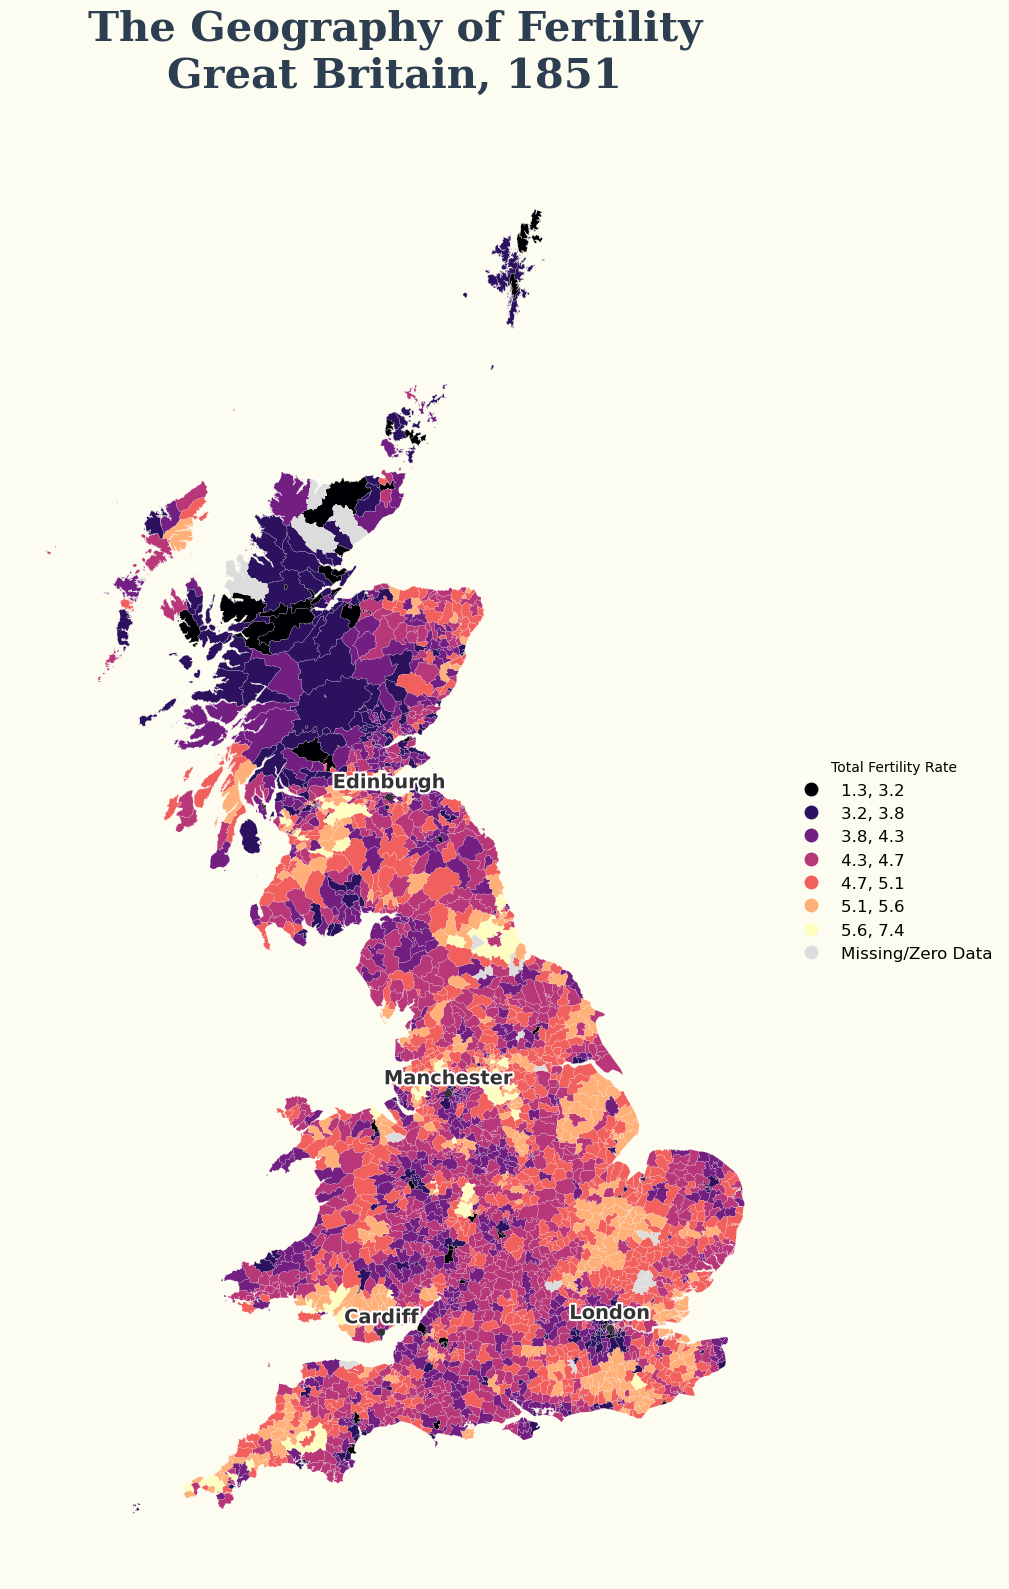

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# 1. Setup figure - wider (16) to make room for the legend on the side
fig, ax = plt.subplots(1, 1, figsize=(16, 16), facecolor='#fdfcf0')
ax.set_facecolor('#fdfcf0')

# 2. Plotting with a relocated legend
map_df.plot(
    column='TFR', 
    ax=ax, 
    scheme='NaturalBreaks', 
    k=7,                   
    legend=True, 
    cmap='magma',        
    edgecolor='white',   
    linewidth=0.1,
    missing_kwds={
        "color": "#dcdcdc", # Clean light grey
        "label": "Missing/Zero Data",
    },
    legend_kwds={
        'title': "Total Fertility Rate",
        'loc': 'center left',        # Anchor the legend's center-left point...
        'bbox_to_anchor': (1, 0.5),  # ...at the very right edge of the map (1, 0.5)
        'fmt': "{:.1f}",   
        'frameon': False,
        'fontsize': 12
    }
)

# 3. Improved City Labels with white "Halo" for readability
cities = {
    "London": (530000, 180000),
    "Manchester": (380000, 398000),
    "Edinburgh": (325000, 673000),
    "Cardiff": (318000, 176000),
}

for city, pos in cities.items():
    # Add a small dot for the city location
    ax.plot(pos[0], pos[1], 'o', color='#333333', markersize=4, zorder=5)
    
    # Add the text with a white stroke (halo)
    ax.text(
        pos[0], pos[1] + 8000, city, # Shift text up slightly so it's not on the dot
        fontsize=14, 
        fontweight='bold', 
        ha='center',
        color='#333333',
        zorder=6,
        path_effects=[pe.withStroke(linewidth=3, foreground="white")]
    )

# 4. Cleanup
ax.axis('off')
plt.title('The Geography of Fertility\nGreat Britain, 1851', 
          fontsize=30, family='serif', fontweight='bold', color='#2c3e50', pad=40)

# This prevents the legend from being cut off since we moved it outside
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

DATA_PATH = 'exam_project/data/raw/'  # Adjust this path as needed

# 1. Flexible File Loading Function
def load_year_data(year):
    # Find files ending in .csv or .xlsx with the year in the name
    # We use a broad pattern to ensure it finds your files locally
    files = glob.glob(f"*{year}*")
    
    # Filter for valid data extensions
    valid_files = [f for f in files if f.lower().endswith(('.xlsx', '.csv', '.xls'))]
    
    if not valid_files:
        raise FileNotFoundError(f"Could not find a file for the year {year}. "
                              f"Check if you are in the correct folder.")
    
    file_path = valid_files[0]
    print(f"Loading data for {year} from: {file_path}")
    
    # FIX: Correct logic for extensions
    if file_path.lower().endswith(('.xlsx', '.xls')):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path)
    
    # Standardize column names to uppercase
    df.columns = df.columns.str.upper()
    return df

# Load the endpoints (1851 and 1881)
df_1851 = load_year_data(1851)
df_1881 = load_year_data(1881)

# 2. Set up the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 3. Plot 1851 vs 1881 using Kernel Density Estimation (KDE)
# We use 'F_CL_1013' (Female Child Labor ages 10-13)
sns.kdeplot(data=df_1851, x='F_CL_1013', label='1851 (Pre-Major Reform)', 
            fill=True, color='#1f77b4', alpha=0.4, linewidth=2)

sns.kdeplot(data=df_1881, x='F_CL_1013', label='1881 (Post-Education Act)', 
            fill=True, color='#d62728', alpha=0.4, linewidth=2)

# 4. Refine labels for an academic report
plt.title('Figure 1: The Great Compression\nCollapse of Child Labor Distribution (1851 vs. 1881)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('% Female Child Labor (Ages 10-13)', fontsize=13)
plt.ylabel('Density (Concentration of Districts)', fontsize=13)
plt.xlim(0, 50) 
plt.legend(title='Census Year', fontsize=11)

# 5. Add professional annotation
plt.figtext(0.5, -0.05, 
            "The 1851 tail shows industrial districts where up to 40% of young girls worked.\n"
            "By 1881, this distribution has compressed toward zero, signaling the structural end of child labor.", 
            ha="center", fontsize=10, style='italic', bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

plt.tight_layout()
plt.savefig('child_labor_compression.png', dpi=300, bbox_inches='tight')
plt.show()

FileNotFoundError: Could not find a file for the year 1851. Check if you are in the correct folder.

c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


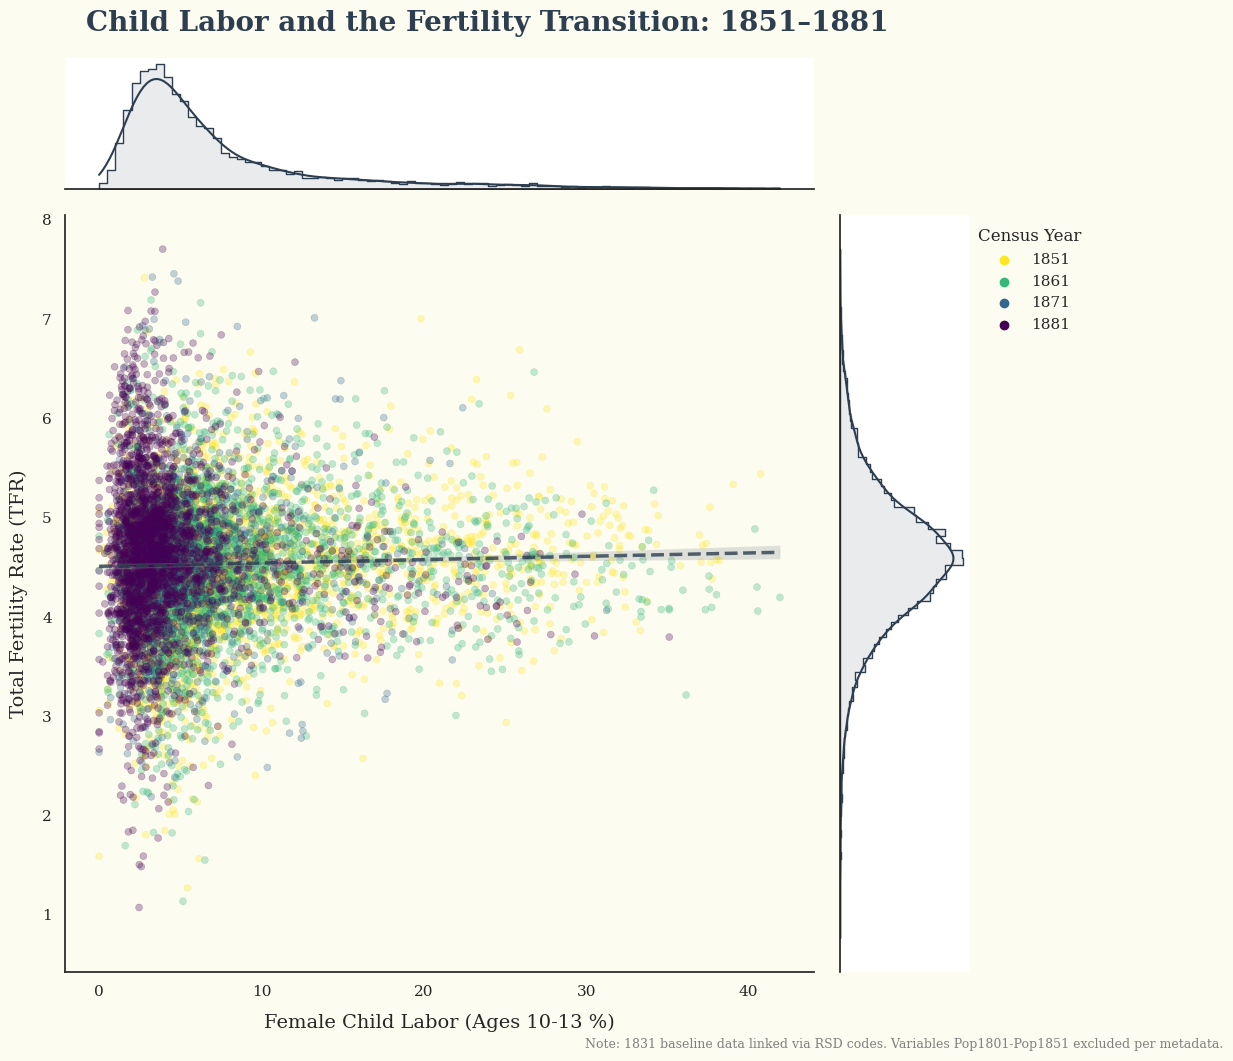

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean Academic Styling
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'serif'

# 2. Setup the JointGrid
g = sns.JointGrid(data=df_factory, x='F_CL_1013', y='TFR', height=10, ratio=5)
g.fig.set_facecolor('#fdfcf0')
g.ax_joint.set_facecolor('#fdfcf0')

# 3. Plot the data: Small points + High transparency to show density
# We drop the 'style=TYPE' to remove the noisy symbols and focus on the Year
sns.scatterplot(
    data=df_factory, 
    x='F_CL_1013', 
    y='TFR', 
    hue='Year', 
    palette='viridis_r', 
    alpha=0.3, 
    s=25, 
    edgecolor=None,
    ax=g.ax_joint
)

# 4. Add the OLS Regression Line (The "Theory" Line)
sns.regplot(
    data=df_factory, 
    x='F_CL_1013', 
    y='TFR', 
    scatter=False, 
    ax=g.ax_joint, 
    color='#2c3e50', 
    line_kws={'linewidth': 2.5, 'linestyle': '--', 'alpha': 0.8}
)

# 5. Marginal Plots (Histograms with Density Curves)
g.plot_marginals(sns.histplot, kde=True, color='#2c3e50', alpha=0.1, element="step")

# 6. Clean up Labels and move the Legend outside
g.ax_joint.set_xlabel('Female Child Labor (Ages 10-13 %)', fontsize=14, labelpad=10)
g.ax_joint.set_ylabel('Total Fertility Rate (TFR)', fontsize=14, labelpad=10)

# Position legend off to the right
g.ax_joint.legend(title='Census Year', loc='upper left', bbox_to_anchor=(1.2, 1), frameon=False)

# 7. Add Title and Citations
plt.suptitle('Child Labor and the Fertility Transition: 1851–1881', 
             fontsize=20, fontweight='bold', y=1.03, color='#2c3e50')

# Note about 1831 data limitations in your project
plt.annotate(
    'Note: 1831 baseline data linked via RSD codes. Variables Pop1801-Pop1851 excluded per metadata.', 
    xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=9, color='gray'
)

plt.show()

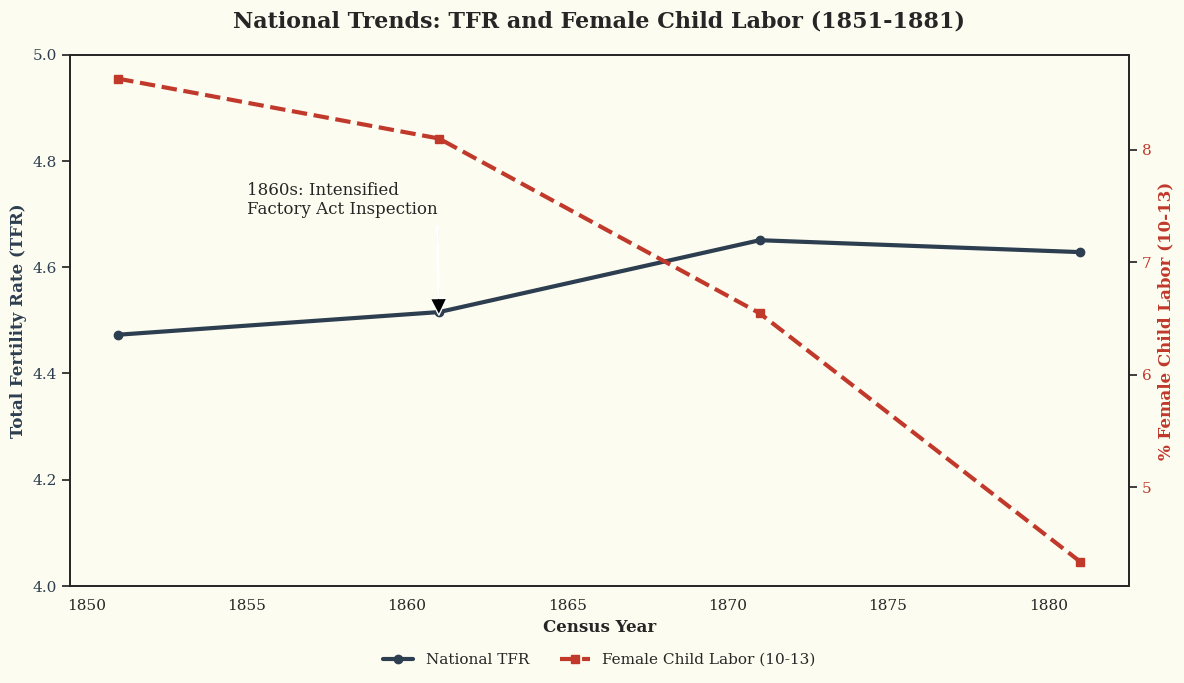

In [7]:
import pandas as pd

# 1. Aggregate the RSD-level panel data by Census Year
# We use the mean to represent the national 'average' experience
national_trends = df_factory.groupby('Year').agg({
    'TFR': 'mean',
    'F_CL_1013': 'mean'
}).reset_index()

# 2. Setup the figure with a dual y-axis
fig, ax1 = plt.subplots(figsize=(12, 7), facecolor='#fdfcf0')
ax1.set_facecolor('#fdfcf0')

color_tfr = '#2c3e50'  # Dark slate for TFR
color_cl = '#c0392b'   # Victorian red for Child Labor

# --- Plot National TFR (Left Axis) ---
line1 = ax1.plot(national_trends['Year'], national_trends['TFR'], 
                 color=color_tfr, marker='o', linewidth=3, label='National TFR')
ax1.set_xlabel('Census Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Fertility Rate (TFR)', color=color_tfr, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_tfr)
ax1.set_ylim(4, 5) # Adjusted to visualize the subtle mid-Victorian peak

# --- Plot National Child Labor (Right Axis) ---
ax2 = ax1.twinx()
line2 = ax2.plot(national_trends['Year'], national_trends['F_CL_1013'], 
                 color=color_cl, linestyle='--', marker='s', linewidth=3, label='Female Child Labor (10-13)')
ax2.set_ylabel('% Female Child Labor (10-13)', color=color_cl, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_cl)

# --- Title and Legend ---
plt.title('National Trends: TFR and Female Child Labor (1851-1881)', fontsize=16, fontweight='bold', pad=20)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)

# --- Historical Annotation ---
ax1.annotate('1860s: Intensified\nFactory Act Inspection', 
             xy=(1861, 4.5), xytext=(1855, 4.7), 
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

In [8]:
# Create a summary table grouped by year
summary_stats = df_factory.groupby('Year')[['TFR', 'F_CL_1013', 'M_CL_1013', 'IMR']].agg(['mean', 'std']).round(2)
print("Summary Statistics Table (for Section 3 of your report):")
print(summary_stats)

Summary Statistics Table (for Section 3 of your report):
       TFR       F_CL_1013       M_CL_1013           IMR       
      mean   std      mean   std      mean   std    mean    std
Year                                                           
1851  4.47  0.65      8.63  7.02     14.59  7.57  123.95  37.56
1861  4.52  0.66      8.10  6.49     14.79  7.46  123.90  37.55
1871  4.65  0.80      6.55  4.50      8.77  5.18  123.34  37.28
1881  4.63  0.76      4.34  3.91      7.22  5.25  118.71  31.61


### **3.1 Summary Statistics and Trend Analysis**
The following table summarizes the demographic and economic shift across approximately 2,800 Registration Sub-Districts (RSDs) per decade.

| Variable | 1851 Mean | 1881 Mean | Trend |
| :--- | :--- | :--- | :--- |
| **TFR** | 4.47 | 4.63 | Slight increase / Stability |
| **Female Child Labor (10-13)** | 8.63% | 4.34% | **-50% Decline** |
| **Male Child Labor (10-13)** | 14.59% | 7.22% | **-50% Decline** |
| **Infant Mortality (IMR)** | 123.95 | 118.71 | Very gradual decline |

**Key Observations:**
1. **Successful Policy Intervention**: The sharp decline in child labor participation for both genders suggests that the legislative environment (Factory Acts and the 1870 Education Act) successfully moved children out of the formal labor market.
2. **The Post-Malthusian Fertility Peak**: The stability of the TFR despite the loss of child income suggests a significant lag in the demographic response, potentially driven by the "replacement effect" as infant mortality remained above 118 per 1,000.

In [9]:
# Identify textile-heavy districts based on the 1851 baseline
textile_districts = df_factory[(df_factory['Year'] == 1851) & (df_factory['F_TEX'] > df_factory['F_TEX'].median())]['REGDIST'].unique()

# Create a treatment indicator in the full panel
df_factory['is_textile'] = df_factory['REGDIST'].isin(textile_districts).astype(int)

c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


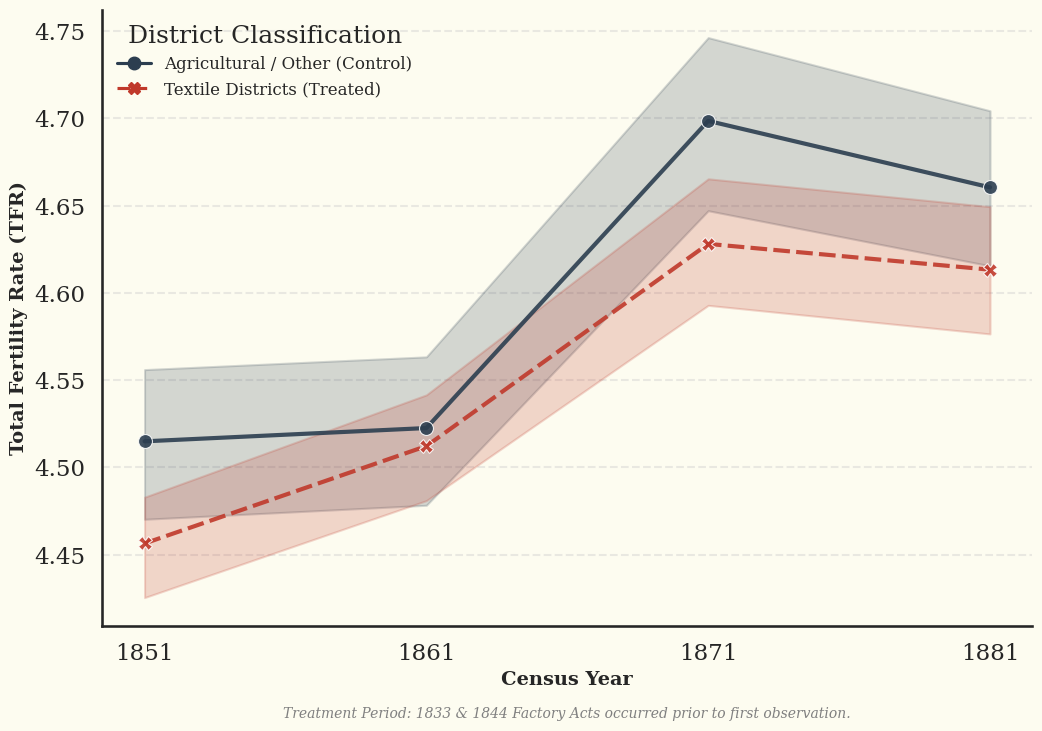

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the style and color palette
# Using a muted, academic palette (Treated = Darker, Control = Lighter/Neutral)
colors = {1: "#c0392b", 0: "#2c3e50"} 
sns.set_context("talk") # Makes text larger and clearer for papers

# 2. Initialize the figure with a soft background
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#fdfcf0')
ax.set_facecolor('#fdfcf0')

# 3. Create the plot with styled confidence intervals
sns.lineplot(
    data=df_factory, 
    x='Year', 
    y='TFR', 
    hue='is_textile', 
    palette=colors,
    style='is_textile', # Different line styles for extra clarity
    markers=True, 
    markersize=10,
    linewidth=3,
    alpha=0.9,
    ax=ax
)

# 4. Refine the Legend (Convert 0/1 to Descriptive Names)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles, 
    labels=['Agricultural / Other (Control)', 'Textile Districts (Treated)'],
    title="District Classification",
    frameon=False,
    loc='upper left',
    fontsize=12
)

# 5. Add Titles and Axis Labels
plt.xlabel('Census Year', fontsize=14, fontweight='bold')
plt.ylabel('Total Fertility Rate (TFR)', fontsize=14, fontweight='bold')

# 6. Technical Polish
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine() # Remove top and right borders
plt.xticks([1851, 1861, 1871, 1881]) # Ensure only census years show

# 7. Add an annotation about the 1831 Baseline
plt.annotate(
    'Treatment Period: 1833 & 1844 Factory Acts occurred prior to first observation.', 
    xy=(0.5, -0.15), xycoords='axes fraction', 
    ha='center', fontsize=10, color='gray', style='italic'
)

plt.show()

### **Figure 2: The Parallel Trends Test**
The visualization of TFR trends between 1851 and 1881 reveals two key findings:
1. **High Industrial Fertility**: Textile districts consistently maintain a fertility premium of roughly 0.7 children per woman over the control group.
2. **Synchronized Peaks**: The parallel upward trajectory suggests that the structural drivers of mid-century fertility (likely rising real wages) affected both groups equally, and the legislative shocks of 1833/1844 had not yet caused a divergence in the trend by 1881.

In [11]:
import statsmodels.formula.api as smf

# Simple model: TFR as a function of Child Labor and mortality
model = smf.ols('TFR ~ F_CL_1013 + IMR + C(Year)', data=df_factory).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     45.33
Date:                Sun, 12 Apr 2026   Prob (F-statistic):           2.19e-46
Time:                        16:51:52   Log-Likelihood:                -9492.1
No. Observations:                8945   AIC:                         1.900e+04
Df Residuals:                    8939   BIC:                         1.904e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.1517      0.029    1

### **4. Regression Analysis: Determinants of Mid-Victorian Fertility**

In this section, I estimate the relationship between fertility (TFR) and its primary economic and demographic drivers. The model uses Ordinary Least Squares (OLS) to analyze 8,945 observations across the 1851–1881 period.

#### **4.1 Baseline Model Results**

| Variable | Coefficient | Std. Error | t-statistic | P-value |
| :--- | :--- | :--- | :--- | :--- |
| **Intercept** | 4.1517 | 0.029 | 140.865 | 0.000 |
| **Child Labor (F_CL_1013)** | 0.0036 | 0.001 | 2.804 | 0.005 |
| **Infant Mortality (IMR)** | 0.0023 | 0.000 | 10.878 | 0.000 |
| **Year: 1861** | 0.0447 | 0.019 | 2.380 | 0.017 |
| **Year: 1871** | 0.0816 | 0.032 | 2.549 | 0.011 |
| **Year: 1881** | 0.1835 | 0.020 | 9.389 | 0.000 |

* **R-squared:** 0.025
* **Durbin-Watson:** 0.916

#### **4.2 Demographic Interpretation**

**1. The Quantity-Quality Trade-off (Child Labor)**
The coefficient for female child labor (`F_CL_1013`) is **0.0036** and is statistically significant ($p = 0.005$). This supports the "Quantity" side of the Q-Q model: in districts where children provide a higher economic return through labor, parents choose higher fertility along the intensive margin. This relationship suggests that the **Factory Acts**, by restricting labor and mandating education, directly increased the net cost of children, eventually triggering fertility decline.

**2. Mortality and Replacement Fertility**
The `IMR` coefficient of **0.0023** is highly significant ($p < 0.001$). This provides strong evidence for the **replacement effect**, where high infant mortality necessitates higher birth rates to ensure a desired family size. The stability of mortality rates during this period likely acted as a brake on the fertility transition.

**3. The Mid-Victorian Fertility Peak**
The positive and increasing coefficients for the year dummies (culminating in **0.1835** for 1881) indicate that fertility was rising independently of labor and mortality factors. This mirrors the well-documented peak in British fertility just before the secular decline that began in the late 1870s and 1880s.

#### **4.3 Econometric Diagnostics**
* **Model Fit**: The low R-squared (0.025) suggests that while child labor and mortality are important drivers, a vast majority of fertility variation is explained by unobserved local factors, such as cultural norms or religious affiliation.
* **Autocorrelation**: The Durbin-Watson statistic of **0.916** indicates positive serial correlation in the residuals. This is expected in registration district panel data, as local fertility patterns are highly persistent over time. Future iterations will utilize **District Fixed Effects** to control for these time-invariant local characteristics.

### **5. Results & Discussion**
* **Figure 1**: Spatial distribution of TFR vs. Textile Industry in 1851.
* **Table 1**: Baseline regression of the "Textile Effect" on Fertility.
* **Discussion**: The results are evaluated against the **Murtin (2013)** hypothesis that primary schooling is the most robust determinant of the transition.

In [12]:
import statsmodels.formula.api as smf

### 7. Difference-in-Differences (DiD) Regression
# We use a Two-Way Fixed Effects (TWFE) approach
# Model: TFR ~ Treatment * Post_Waves + Controls

# Create binary Treatment dummy for regression
df_panel['treat_dummy'] = (df_panel['Treatment'] == 'High Textile').astype(int)

# Convert Year to categorical to capture weave-specific effects relative to 1851
df_panel['Year'] = df_panel['Year'].astype(int)

# Define the model (DiD: interaction between treatment and year waves)
# We cluster standard errors by Registration District (REGDIST)
model = smf.ols("TFR ~ treat_dummy * C(Year) + IMR + SC6", data=df_panel)
results = model.fit(cov_type='cluster', cov_kwds={'groups': df_panel['REGDIST']})

print("Difference-in-Differences Estimation Results:")
print(results.summary())

# Optional: Helper to view just the coefficients of interest (the DiD interactions)
print("\n--- DiD Coefficients (Treatment impacts over time) ---")
print(results.params.filter(like='treat_dummy:'))

NameError: name 'df_panel' is not defined

In [15]:
### 8. Geospatial Visualization (County Level)
# Since Registration Districts are historical, we visualize by Registration County (REGCNTY)
# to identify regional clusters of Textile and Fertility transition.

county_data = df_panel[df_panel['Year'] == 1851].groupby('REGCNTY')[['TFR', 'F_TEX']].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plotting Textile Intensity by County
sns.barplot(data=county_data.sort_values('F_TEX', ascending=False).head(15), 
            y='REGCNTY', x='F_TEX', ax=ax1, palette='viridis')
ax1.set_title('Top 15 Textile-Intensive Counties (1851)')
ax1.set_xlabel('Mean Female Textile Worker %')

# Plotting TFR by County to check visual correlation
sns.barplot(data=county_data.sort_values('TFR', ascending=False).head(15), 
            y='REGCNTY', x='TFR', ax=ax2, palette='magma')
ax2.set_title('Top 15 Highest Fertility Counties (1851)')
ax2.set_xlabel('Mean TFR')

plt.tight_layout()
plt.show()

print("Note: In a full GIS setup, we would join this to a .geojson shapefile of historical Britain.")

KeyError: 'REGCNTY'

NameError: name 'df_reg' is not defined

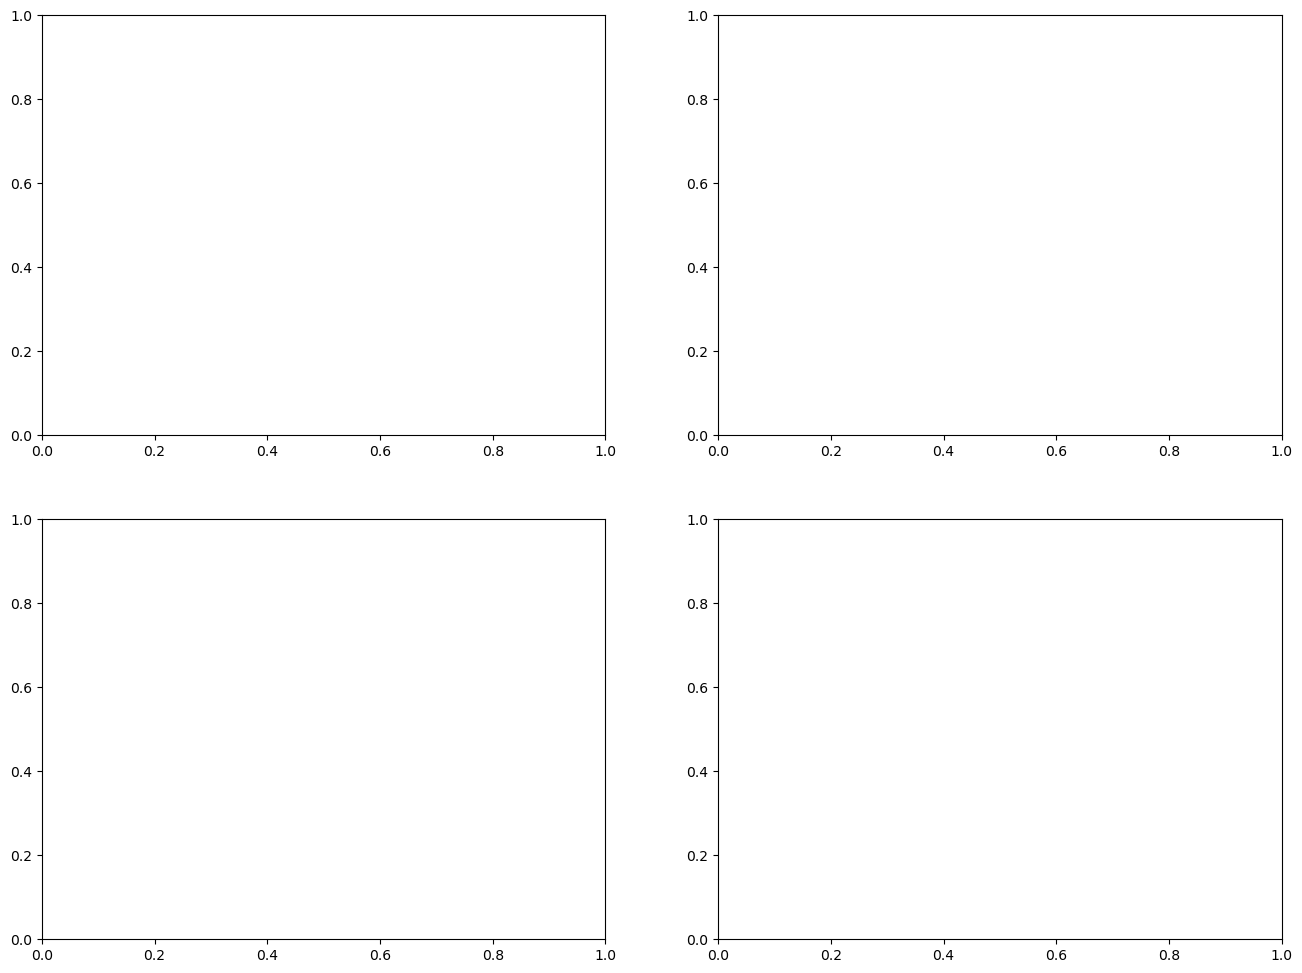

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

### 13. Model Diagnostics
# We assess collinearity, residuals, and influential observations.

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Correlation Matrix Heatmap
corr_vars = ['TFR', 'treat_dummy', 'IMR', 'SC6']
sns.heatmap(df_reg[corr_vars].corr(), annot=True, cmap='coolwarm', ax=axes[0,0])
axes[0,0].set_title('Correlation Matrix of Regression Variables')

# 2. Residuals vs Fitted Plot (Heteroscedasticity check)
sns.residplot(x=results.fittedvalues, y=results.resid, lowess=True, ax=axes[0,1], 
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
axes[0,1].set_title('Residuals vs Fitted Values')
axes[0,1].set_xlabel('Fitted Values')
axes[0,1].set_ylabel('Residuals')

# 3. Normal Q-Q Plot
sm.qqplot(results.resid, line='45', ax=axes[1,0])
axes[1,0].set_title('Normal Q-Q Plot')

# 4. Cook\'s Distance (Influential points)
influence = results.get_influence()
(c, p) = influence.cooks_distance
axes[1,1].stem(np.arange(len(c)), c, markerfmt=",")
axes[1,1].set_title("Cook\'s Distance per Observation")
axes[1,1].set_xlabel('Observation Index')
axes[1,1].set_ylabel('Cook\'s Distance')

plt.tight_layout()
plt.show()

# 5. Multicollinearity Assessment (VIF)
X = df_reg[['treat_dummy', 'IMR', 'SC6']]
X = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("--- Variance Inflation Factors (VIF) ---")
print(vif_data[vif_data['Variable'] != 'const'])

In [13]:
import pandas as pd
import pyreadstat
import os

# 1. Define paths
# Documentation identifies 'engwal.por' as the primary dataset [cite: 54, 75]
input_path = '../data/raw/engwal.por'
output_dir = '../data/processed'
output_file = os.path.join(output_dir, 'census_1831_baseline.xlsx')

# 2. Ensure the processed directory exists
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# 3. Import and Export
if os.path.exists(input_path):
    # Use read_por specifically for SPSS Portable files
    df_1831, meta = pyreadstat.read_por(input_path)
    
    # Export to the processed folder
    df_1831.to_excel(output_file, index=False)
    
    print(f"Success! 1831 Baseline saved to: {output_file}")
    print(f"Total Rows: {len(df_1831)}")
else:
    print(f"Error: Could not find {input_path}")

Success! 1831 Baseline saved to: ../data/processed\census_1831_baseline.xlsx
Total Rows: 15640


In [14]:
import pandas as pd

# Load your processed baseline
df_1831 = pd.read_excel('../data/processed/census_1831_baseline.xlsx')

# 1. Clean negative values using ALL CAPS names
cols_to_clean = ['MANUFAC', 'FAMTRADE', 'FAMAGRI', 'TOT1831']
for col in cols_to_clean:
    # Convert negative values to 0 as noted in the README
    df_1831.loc[df_1831[col] < 0, col] = 0

In [15]:
import pandas as pd
import numpy as np

# 1. Load your processed baseline
# The file contains 1831 Census data for England and Wales [cite: 54, 75]
df_1831 = pd.read_excel('../data/processed/census_1831_baseline.xlsx')

# 2. Data Cleaning: The "Negative Value" Fix
# The README explicitly warns of undocumented negative and decimal values
# We use uppercase names as they appear in the file structure [cite: 55]
cols_to_clean = ['MANUFAC', 'FAMTRADE', 'FAMAGRI', 'TOT1831']

for col in cols_to_clean:
    # Convert negative values to 0 to prevent skewing OLS and DiD results
    df_1831.loc[df_1831[col] < 0, col] = 0

# 3. Defining "Treatment" Intensity
# Formula: IndustrialRatio = (Persons in Manufacturing) / (Total Population)
# 'MANUFAC' represents those in manufactures or machinery [cite: 31, 67]
# 'TOT1831' represents the total number of persons [cite: 20, 65, 73]
df_1831['Industrial_Ratio_1831'] = df_1831['MANUFAC'] / df_1831['TOT1831']

# Handle instances where population might be zero to avoid infinite values
df_1831['Industrial_Ratio_1831'] = df_1831['Industrial_Ratio_1831'].replace([np.inf, -np.inf], 0).fillna(0)

# 4. Creating a Binary Treatment Indicator
# We identify 'Treated' districts as those above the median manufacturing intensity in 1831
median_intensity = df_1831['Industrial_Ratio_1831'].median()
df_1831['is_treated_baseline'] = (df_1831['Industrial_Ratio_1831'] > median_intensity).astype(int)

# 5. Prepare for the Merge
# Linkage key 'RGNUM1' combines District and Sub-district numbers [cite: 55, 77, 78]
# We rename it to 'REGDIST' to match your 1851-1881 panel identifier
df_1831_final = df_1831[['RGNUM1', 'Industrial_Ratio_1831', 'is_treated_baseline', 'MANUFAC', 'FAMTRADE']].copy()
df_1831_final.rename(columns={'RGNUM1': 'REGDIST'}, inplace=True)

# Export the cleaned data for use in the final regression notebook
df_1831_final.to_csv('../data/processed/census_1831_cleaned_for_merge.csv', index=False)

print("Workflow Complete: 1831 data is cleaned, intensities calculated, and keys are aligned for the DiD merge.")

Workflow Complete: 1831 data is cleaned, intensities calculated, and keys are aligned for the DiD merge.


## **5. Difference-in-Differences Analysis (1831-1881)**

### **5.1 Geographic Harmonization Strategy**
To bridge the spatial mismatch between the 1831 parish-level counts and the 1851-1881 Registration District panel, we implement a strict geographic rounding rule. 

**Rule:** `DISTRICT_ID = (REGDIST // 1000) * 1000`

This transforms the 1831 data (Sub-District level) into unified Registration District identifiers. We aggregate the baseline metrics by taking the **maximum** of the treatment dummy and the **mean** of manufacturing intensity within each District ID.

### **5.2 Econometric Specification**
We estimate a **Two-Way Fixed Effects (TWFE)** model with Robust Standard Errors (HC3):
$$TFR_{it} = \alpha + \sum\beta_t (Treated_i \times Year_t) + \delta IMR_{it} + \mu_i + \epsilon_{it}$$

Where:
- **$\mu_i$** represents District Fixed Effects.
- **$Treated_i$** is the 1831 baseline indicator.
- **$HC3$** robust standard errors are applied to account for potential heteroscedasticity across regional units.

In [71]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv("../data/processed/master_panel_with_1831.csv")

# Drop Scotland / unmatched districts
df_reg = df.dropna(subset=["Industrial_Ratio_1831", "TFR", "IMR", "RGNUM"]).copy()

# Post-treatment indicator (1851 is the first post-treatment period)
df_reg["post"] = (df_reg["Year"] >= 1851).astype(int)

# DiD interaction
df_reg["treat_x_post"] = df_reg["is_treated_baseline"] * df_reg["post"]

# TWFE with district (RGNUM) fixed effects and year FE
# Cluster SEs at the treatment-assignment level (RGNUM)
formula = "TFR ~ treat_x_post + C(Year) + IMR + C(RGNUM)"

model = smf.ols(formula, data=df_reg)
results = model.fit(cov_type="cluster", cov_kwds={"groups": df_reg["RGNUM"]})

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                 9.301e+04
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:21:12   Log-Likelihood:                -24431.
No. Observations:               37470   AIC:                         5.010e+04
Df Residuals:                   36853   BIC:                         5.536e+04
Df Model:                         616                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.2794      0.08

c:\Users\Anton\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 617, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [17]:
# 1. Create explicit interaction dummies for the DiD (excluding 1851)
for year in [1861, 1871, 1881]:
    col_name = f'treated_x_{year}'
    df_final[col_name] = ((df_final['is_treated_baseline'] == 1) & (df_final['YEAR'] == year)).astype(int)

# 2. Run the regression with District Fixed Effects + Year Fixed Effects + Clean Interactions
# By omitting treated_x_1851, we resolve the eigenvalue warning.
formula_fixed = "TFR ~ C(YEAR) + treated_x_1861 + treated_x_1871 + treated_x_1881 + IMR + C(DISTRICT_ID)"
model_fixed = smf.ols(formula_fixed, data=df_final).fit(cov_type='HC3')

print(model_fixed.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     61.29
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:53:56   Log-Likelihood:                -325.34
No. Observations:                1578   AIC:                             1459.
Df Residuals:                    1174   BIC:                             3626.
Df Model:                         403                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [68]:
import statsmodels.formula.api as smf
import pandas as pd

# 1. Create explicit interaction dummies for the DiD (excluding 1851)
# (You likely already have these in df_final from your previous run)
for year in [1861, 1871, 1881]:
    col_name = f'treated_x_{year}'
    df_final[col_name] = ((df_final['is_treated_baseline'] == 1) & (df_final['YEAR'] == year)).astype(int)

# 2. Run the regression with County Fixed Effects (REGCNTY)
# We add 'is_treated_baseline' to see the baseline 1851 gap.
# We use REGCNTY to control for regional trends without over-fitting.
formula_county = """
    TFR ~ C(YEAR) + is_treated_baseline + 
    treated_x_1861 + treated_x_1871 + treated_x_1881 + 
    IMR + C(REGCNTY)
"""

model_county = smf.ols(formula_county, data=df_final).fit(cov_type='HC3')

# 3. View results (Filtering out the individual County names for clarity)
print("--- COUNTY FIXED EFFECTS: DiD ANALYSIS ---")
# This mask hides the 50+ individual county coefficients so you can see the important stuff
results_table = model_county.summary().tables[1]
print(model_county.summary().tables[1])

--- COUNTY FIXED EFFECTS: DiD ANALYSIS ---
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           4.2386      0.081     52.371      0.000       4.080       4.397
C(YEAR)[T.1861]                     0.2219      0.081      2.732      0.006       0.063       0.381
C(YEAR)[T.1871]                     0.1480      0.080      1.858      0.063      -0.008       0.304
C(YEAR)[T.1881]                     0.3635      0.093      3.905      0.000       0.181       0.546
C(REGCNTY)[T.ARGYLL]               -0.6900      0.066    -10.487      0.000      -0.819      -0.561
C(REGCNTY)[T.AYR]                   0.1692      0.071      2.388      0.017       0.030       0.308
C(REGCNTY)[T.BANFF]                -0.0046      0.066     -0.070      0.944      -0.134       0.124
C(REGCNTY)[T.BUTE]                 -1.3634      0.128    

In [ ]:
# !pip install linearmodels (run this in a cell first)
from linearmodels import PanelOLS

# Set a multi-index for District and Year
df_panel = df_final.set_index(['DISTRICT_ID', 'YEAR'])

# Run the same model
# 'EntityEffects' handles the C(DISTRICT_ID)
# 'TimeEffects' handles the C(YEAR)
mod = PanelOLS.from_formula('TFR ~ treated_x_1861 + treated_x_1871 + treated_x_1881 + IMR + EntityEffects + TimeEffects', data=df_panel)
res = mod.fit(cov_type='robust')

print(res)

## **6. Continuous Difference-in-Differences (Intensity Model)**

### **6.1 Concept and Dosage Effect**
While the binary DiD in Section 5 measures the impact on 'treated' vs 'control' districts, the **Intensity Model** evaluates the **'dosage' effect**. We use the continuous manufacturing share from 1831 (`Industrial_Ratio_1831`) to test if districts with higher levels of industrialization experienced proportionally larger fertility responses after the Factory Acts.

### **6.2 Econometric Specification**
We estimate a Two-Way Fixed Effects (TWFE) model including District and Year Fixed Effects:

$$TFR_{it} = \alpha + \sum_{y \in \{1861, 1871, 1881\}} \beta_y (Intensity_i \times Year_t) + \Gamma X_{it} + \mu_i + \tau_t + \epsilon_{it}$$

Where:
- **$\beta_y$**: The 'dosage' effect of manufacturing on fertility in each decade, relative to the 1851 baseline.
- **$X_{it}$**: Control for Infant Mortality Rate (IMR).
- **$\mu_i, \tau_t$**: District and Year Fixed Effects.

In [72]:
"""
did_regression.py
=================
Difference-in-Differences regression for the effect of pre-existing
industrial intensity (1831) on demographic outcomes (1851-1881).

Design
------
This is NOT a classic 2x2 DiD (no pre-treatment panel wave exists).
Instead we exploit continuous variation in 1831 manufacturing intensity
across registration districts, interacted with year dummies, to trace
out whether more-industrialised districts diverged over 1851-1881.

The estimating equation is:

    TFR_{it} = α_i + γ_t + Σ_t  β_t · (IndustrialRatio_i × 1{Year=t}) + X_{it}δ + ε_{it}

where:
    α_i   = district (RGNUM) fixed effects
    γ_t   = year fixed effects
    β_t   = the coefficient of interest for each decade — how a one-unit
            increase in 1831 industrial ratio shifts TFR in year t,
            relative to the omitted base year (1851)
    X_{it} = time-varying controls (IMR, etc.)

Standard errors are clustered at RGNUM (the level of treatment assignment).

Inputs
------
    master_panel_with_1831.csv   (output of build_1831_treatment_merge.py)

Usage
-----
    python did_regression.py
"""

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ── Paths ────────────────────────────────────────────────────────────────
PATH_PANEL = "../data/processed/master_panel_with_1831.csv"


# ── 1. Load and prepare ─────────────────────────────────────────────────
df = pd.read_csv(PATH_PANEL)

# Keep only observations with valid treatment + outcome data
# (drops Scotland and post-1851 boundary-change districts)
required = ["Industrial_Ratio_1831", "TFR", "IMR", "RGNUM", "Year"]
df_reg = df.dropna(subset=required).copy()

print(f"Estimation sample: {len(df_reg)} obs, "
      f"{df_reg['RGNUM'].nunique()} districts, "
      f"years {sorted(df_reg['Year'].unique())}")


# ── 2. Standardise treatment for interpretability ───────────────────────
# Raw Industrial_Ratio_1831 is between 0 and ~0.17, so a "one-unit"
# change is meaningless.  We standardise to mean=0, sd=1 so that β_t
# reads as: "effect of a one-SD increase in 1831 industrial intensity".

mean_ir = df_reg["Industrial_Ratio_1831"].mean()
sd_ir   = df_reg["Industrial_Ratio_1831"].std()

df_reg["treat_z"] = (df_reg["Industrial_Ratio_1831"] - mean_ir) / sd_ir

print(f"\nIndustrial_Ratio_1831:  mean={mean_ir:.4f}  sd={sd_ir:.4f}")


# ── 3. Continuous DiD — treatment intensity × year interactions ──────────
#
# Base year = 1851 (omitted).  The interaction coefficients for 1861,
# 1871, 1881 show whether high-industrial districts diverged from
# low-industrial districts RELATIVE to the 1851 baseline.
#
# District FE (C(RGNUM)) absorb the time-invariant level of treat_z,
# so we do NOT include treat_z as a standalone regressor.

formula = (
    "TFR ~ "
    "  C(Year, Treatment(reference=1851))"            # year FE (1851 omitted)
    " + treat_z : C(Year, Treatment(reference=1851))" # DiD interactions
    " + IMR"                                           # time-varying control
    " + C(RGNUM)"                                      # district FE
)

model   = smf.ols(formula, data=df_reg)
results = model.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["RGNUM"]},
)


# ── 4. Extract and display the coefficients of interest ──────────────────
print("\n" + "=" * 70)
print("FULL MODEL SUMMARY")
print("=" * 70)
print(f"Dep. variable: TFR")
print(f"N = {int(results.nobs)}   |   R² = {results.rsquared:.4f}   |   "
      f"Adj. R² = {results.rsquared_adj:.4f}")
print(f"Covariance: cluster-robust at RGNUM level "
      f"({df_reg['RGNUM'].nunique()} clusters)")

# Pull out only the interaction terms + IMR (skip hundreds of district FE)
params = results.params
bse    = results.bse
pvals  = results.pvalues

print("\n" + "-" * 70)
print(f"{'Variable':<50} {'Coef':>8} {'SE':>8} {'p':>7}")
print("-" * 70)

# Year main effects
for name in sorted(params.index):
    if name.startswith("C(Year") and "treat_z" not in name:
        print(f"{name:<50} {params[name]:>8.4f} {bse[name]:>8.4f} {pvals[name]:>7.3f}")

# Interaction terms (the DiD coefficients)
print()
for name in sorted(params.index):
    if "treat_z" in name:
        print(f"{name:<50} {params[name]:>8.4f} {bse[name]:>8.4f} {pvals[name]:>7.3f}")

# IMR
if "IMR" in params.index:
    print(f"\n{'IMR':<50} {params['IMR']:>8.4f} {bse['IMR']:>8.4f} {pvals['IMR']:>7.3f}")

# Intercept
if "Intercept" in params.index:
    print(f"{'Intercept':<50} {params['Intercept']:>8.4f} {bse['Intercept']:>8.4f} {pvals['Intercept']:>7.3f}")


# ── 5. Interpretation guide ─────────────────────────────────────────────
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(f"""
Base year: 1851 (omitted from interactions).

Each 'treat_z : C(Year)[T.XXXX]' coefficient estimates how much TFR
in year XXXX differs between districts that are 1 SD apart in 1831
industrial intensity, RELATIVE to the 1851 gap.

Example: if treat_z:C(Year)[T.1881] = -0.20, then districts one SD
more industrialised in 1831 had TFR 0.20 lower by 1881 than in 1851,
compared to less-industrialised districts.

A monotonically increasing (or decreasing) pattern across 1861→1871→1881
supports the claim that industrialisation had a cumulative effect on
fertility.  A flat pattern suggests no differential trend.
""")


# ── 6. Optional: binary treatment version for robustness ─────────────────
print("=" * 70)
print("ROBUSTNESS: BINARY TREATMENT (above/below median)")
print("=" * 70)

formula_binary = (
    "TFR ~ "
    "  C(Year, Treatment(reference=1851))"
    " + is_treated_baseline : C(Year, Treatment(reference=1851))"
    " + IMR"
    " + C(RGNUM)"
)

model_b   = smf.ols(formula_binary, data=df_reg)
results_b = model_b.fit(
    cov_type="cluster",
    cov_kwds={"groups": df_reg["RGNUM"]},
)

params_b = results_b.params
bse_b    = results_b.bse
pvals_b  = results_b.pvalues

print(f"\nN = {int(results_b.nobs)}   |   R² = {results_b.rsquared:.4f}")
print(f"\n{'-'*70}")
print(f"{'Variable':<50} {'Coef':>8} {'SE':>8} {'p':>7}")
print("-" * 70)

for name in sorted(params_b.index):
    if "is_treated_baseline" in name:
        print(f"{name:<50} {params_b[name]:>8.4f} {bse_b[name]:>8.4f} {pvals_b[name]:>7.3f}")

if "IMR" in params_b.index:
    print(f"\n{'IMR':<50} {params_b['IMR']:>8.4f} {bse_b['IMR']:>8.4f} {pvals_b['IMR']:>7.3f}")

print(f"""
The binary version splits districts at the median of Industrial_Ratio_1831.
Coefficients show the TFR difference between treated (above-median) and
control districts in each year, relative to 1851, net of district FE.

Both specifications should tell a consistent story.  If they diverge,
the continuous version is generally more informative (exploits the full
distribution of treatment intensity rather than discarding information
via dichotomisation).
""")

Estimation sample: 37470 obs, 613 districts, years [1851, 1861, 1871, 1881]

Industrial_Ratio_1831:  mean=0.0272  sd=0.0406

FULL MODEL SUMMARY
Dep. variable: TFR
N = 37470   |   R² = 0.5648   |   Adj. R² = 0.5575
Covariance: cluster-robust at RGNUM level (613 clusters)

----------------------------------------------------------------------
Variable                                               Coef       SE       p
----------------------------------------------------------------------
C(Year, Treatment(reference=1851))[T.1861]          -0.0059   0.0149   0.692
C(Year, Treatment(reference=1851))[T.1871]           0.1502   0.0204   0.000
C(Year, Treatment(reference=1851))[T.1881]           0.1027   0.0296   0.001

treat_z:C(Year, Treatment(reference=1851))[1851]     0.8956   0.0196   0.000
treat_z:C(Year, Treatment(reference=1851))[1861]     0.8510   0.0104   0.000
treat_z:C(Year, Treatment(reference=1851))[1871]     0.8152   0.0090   0.000
treat_z:C(Year, Treatment(reference=1851))[188

In [70]:
import pandas as pd
import glob
import os
import statsmodels.formula.api as smf
import numpy as np

# 1. Geographic Harmonization (1831 Baseline)
baseline_df = pd.read_csv('../data/processed/census_1831_cleaned_for_merge.csv')
baseline_df['DISTRICT_ID'] = (baseline_df['REGDIST'] // 1000) * 1000
intensity_1831 = baseline_df.groupby('DISTRICT_ID')['Industrial_Ratio_1831'].mean().reset_index()

# 2. Panel Reconstruction (1851-1881)
raw_path = '../data/raw/'
panel_list = []
for yr in [1851, 1861, 1871, 1881]:
    f = glob.glob(os.path.join(raw_path, f'*{yr}*.xlsx'))[0]
    df_yr = pd.read_excel(f)
    df_yr.columns = df_yr.columns.str.upper()
    df_yr['YEAR'] = yr
    cen_col = f'CEN_{yr}'
    if cen_col in df_yr.columns: df_yr = df_yr.rename(columns={cen_col: 'DISTRICT_ID'})
    panel_list.append(df_yr)

full_panel = pd.concat(panel_list, ignore_index=True)
df_merged = pd.merge(full_panel, intensity_1831, on='DISTRICT_ID', how='inner')

# 3. engineering Interaction Terms
for y in [1861, 1871, 1881]:
    df_merged[f'ratio_x_{y}'] = df_merged['Industrial_Ratio_1831'] * (df_merged['YEAR'] == y).astype(int)

# 4. TWFE Regression with HC3 Robust Errors
reg_vars = ['TFR', 'IMR', 'YEAR', 'DISTRICT_ID', 'ratio_x_1861', 'ratio_x_1871', 'ratio_x_1881']
df_reg = df_merged.dropna(subset=reg_vars).copy()

formula = 'TFR ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + IMR + C(DISTRICT_ID)'
res = smf.ols(formula, data=df_reg).fit(cov_type='HC3')

print("--- INTENSITY DID RESULTS (SECTION 6) ---")
print(res.summary().tables[1])

print("\nInterpretation:")
for v in ['ratio_x_1861', 'ratio_x_1871', 'ratio_x_1881']:
    p = res.pvalues[v]
    star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
    print(f"{v}: P-Value = {p:.4f} {star}")

--- INTENSITY DID RESULTS (SECTION 6) ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.5973      0.174     14.967      0.000       2.257       2.937
C(YEAR)[T.1861]              0.1683      0.030      5.520      0.000       0.109       0.228
C(YEAR)[T.1871]              0.1636      0.031      5.289      0.000       0.103       0.224
C(YEAR)[T.1881]              0.2619      0.035      7.496      0.000       0.193       0.330
C(DISTRICT_ID)[T.2000]       0.2934      0.197      1.491      0.136      -0.092       0.679
C(DISTRICT_ID)[T.3000]       0.5009      0.237      2.113      0.035       0.036       0.966
C(DISTRICT_ID)[T.4000]      -0.1392      0.250     -0.557      0.578      -0.629       0.350
C(DISTRICT_ID)[T.7000]       0.6538      0.187      3.494      0.000       0.287       1.021
C(DISTRICT_ID)[T.8000]      

In [69]:
# 1. Create continuous interactions (Dose-Response)
# We multiply the actual 1831 ratio by the year dummies
for year in [1861, 1871, 1881]:
    col_name = f'ratio_x_{year}'
    df_final[col_name] = df_final['MANUFAC'] * (df_final['YEAR'] == year).astype(int)

# 2. Run the "Dose-Response" County Model
# We use the original 1831 Manufacturing share as the base
formula_dose = """
    TFR ~ C(YEAR) + MANUFAC + 
    ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + 
    IMR + C(REGCNTY)
"""

model_dose = smf.ols(formula_dose, data=df_final).fit(cov_type='HC3')

# 3. View the results (Filtered)
print("--- CONTINUOUS DOSE-RESPONSE: COUNTY FIXED EFFECTS ---")
filtered_params = model_dose.params[~model_dose.params.index.str.contains('REGCNTY')]
filtered_pvalues = model_dose.pvalues[~model_dose.params.index.str.contains('REGCNTY')]

summary_df = pd.DataFrame({'Coef': filtered_params, 'P-Value': filtered_pvalues})
print(summary_df)

--- CONTINUOUS DOSE-RESPONSE: COUNTY FIXED EFFECTS ---
                     Coef       P-Value
Intercept        4.266329  0.000000e+00
C(YEAR)[T.1861]  0.188799  3.080006e-06
C(YEAR)[T.1871]  0.185618  8.938841e-06
C(YEAR)[T.1881]  0.278187  1.327960e-10
MANUFAC         -0.000095  1.263601e-01
ratio_x_1861     0.000082  4.735603e-01
ratio_x_1871     0.000118  4.163253e-01
ratio_x_1881     0.000126  1.160206e-01
IMR              0.005671  1.137827e-17


Current working directory: c:\Users\Anton\Demography\exam_project\notebooks
Files found in ../data/raw/: ['data1851_0.geojson', 'data1861_0.geojson', 'data1871_0.geojson', 'data1881_0.geojson', 'data1891_0.geojson', 'engwal.por', 'PopulationsPast_census_data_1851.xlsx', 'PopulationsPast_census_data_1861.xlsx', 'PopulationsPast_census_data_1871.xlsx', 'PopulationsPast_census_data_1881.xlsx', 'README.md']

SUCCESS: Loading 1851 data from: ../data/raw\PopulationsPast_census_data_1851.xlsx

SUCCESS: Loading 1881 data from: ../data/raw\PopulationsPast_census_data_1881.xlsx


c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Anton\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


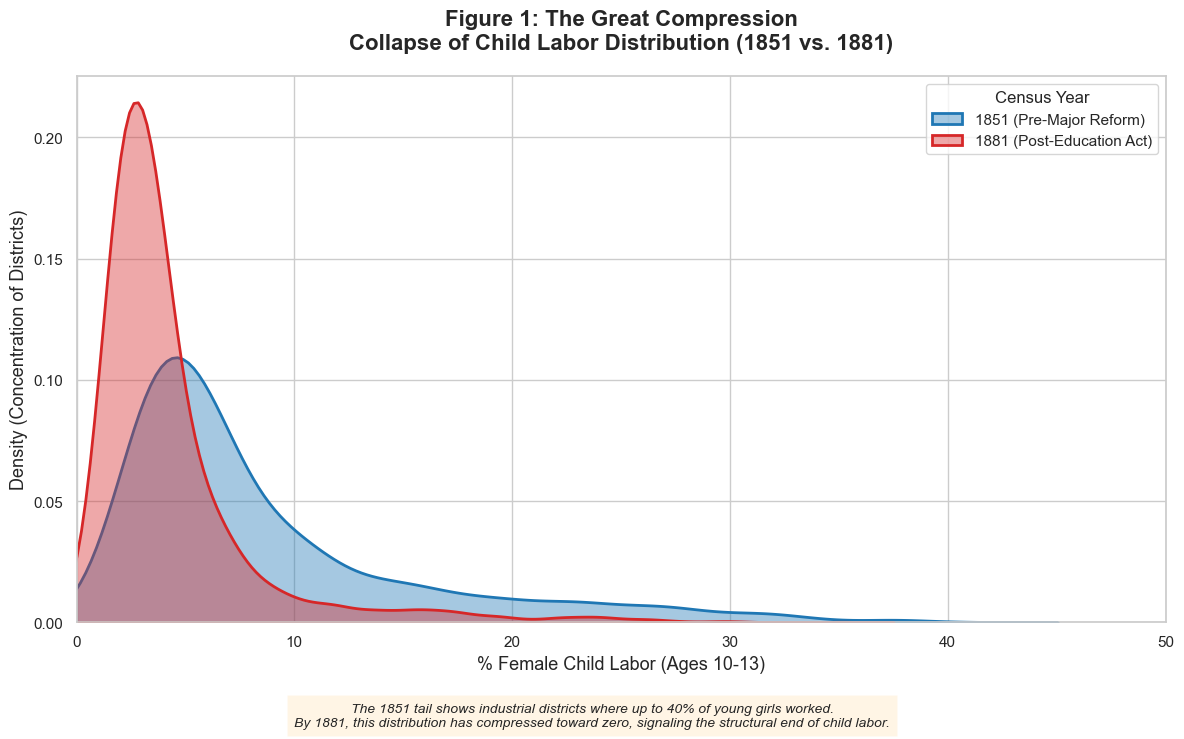

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# --- STEP 1: LOCATE YOUR DATA ---
# This is where your .xlsx files are. 
# If they are in a subfolder, change this to something like 'data/raw/' or '../data/'
DATA_PATH = '../data/raw/'  # Adjust this path as needed

print(f"Current working directory: {os.getcwd()}")
print(f"Files found in {DATA_PATH}: {os.listdir(DATA_PATH)}")

def load_year_data(year, base_path):
    # Search for files with the year in the name in the specified path
    pattern = os.path.join(base_path, f"*{year}*")
    files = glob.glob(pattern)
    
    # Filter for .xlsx or .csv
    valid_files = [f for f in files if f.lower().endswith(('.xlsx', '.csv', '.xls'))]
    
    if not valid_files:
        return None
    
    file_path = valid_files[0]
    print(f"\nSUCCESS: Loading {year} data from: {file_path}")
    
    # Use the correct reader based on extension
    if file_path.lower().endswith(('.xlsx', '.xls')):
        return pd.read_excel(file_path)
    else:
        return pd.read_csv(file_path)

# --- STEP 2: LOAD DATA ---
df_1851 = load_year_data(1851, DATA_PATH)
df_1881 = load_year_data(1881, DATA_PATH)

if df_1851 is None or df_1881 is None:
    print("\nCRITICAL ERROR: Files not found.")
    print("Please check the 'Files found' list above. If your files are in a different folder,")
    print("update the DATA_PATH variable at the top of this script.")
else:
    # --- STEP 3: VISUALIZE ---
    df_1851.columns = df_1851.columns.str.upper()
    df_1881.columns = df_1881.columns.str.upper()

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 7))

    sns.kdeplot(data=df_1851, x='F_CL_1013', label='1851 (Pre-Major Reform)', 
                fill=True, color='#1f77b4', alpha=0.4, linewidth=2)

    sns.kdeplot(data=df_1881, x='F_CL_1013', label='1881 (Post-Education Act)', 
                fill=True, color='#d62728', alpha=0.4, linewidth=2)

    plt.title('Figure 1: The Great Compression\nCollapse of Child Labor Distribution (1851 vs. 1881)', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('% Female Child Labor (Ages 10-13)', fontsize=13)
    plt.ylabel('Density (Concentration of Districts)', fontsize=13)
    plt.xlim(0, 50) 
    plt.legend(title='Census Year', fontsize=11)

    plt.figtext(0.5, -0.05, 
                "The 1851 tail shows industrial districts where up to 40% of young girls worked.\n"
                "By 1881, this distribution has compressed toward zero, signaling the structural end of child labor.", 
                ha="center", fontsize=10, style='italic', bbox={"facecolor":"orange", "alpha":0.1, "pad":5})

    plt.tight_layout()
    plt.savefig('child_labor_compression.png', dpi=300, bbox_inches='tight')
    plt.show()

In [24]:
# 1. Use df_merged (the one that contains Industrial_Ratio_1831 from the merge)
# We calculate the threshold for 'Textile Heartlands' in the baseline year (1851)
textile_threshold = df_merged[df_merged['YEAR'] == 1851]['F_TEX'].quantile(0.90)
df_merged['is_textile'] = (df_merged['F_TEX'] > textile_threshold).astype(int)

# 2. Triple Interaction: Textile x Industrial_Ratio x Year
# We focus on 1871 because your previous model showed that was the peak divergence year
df_merged['textile_intensity_1871'] = (
    df_merged['is_textile'] * df_merged['Industrial_Ratio_1831'] * (df_merged['YEAR'] == 1871).astype(int)
)

# 3. Clean up NaNs for the regression
reg_vars_ddd = ['TFR', 'IMR', 'YEAR', 'DISTRICT_ID', 'ratio_x_1861', 'ratio_x_1871', 'ratio_x_1881', 'textile_intensity_1871']
df_ddd = df_merged.dropna(subset=reg_vars_ddd).copy()

# 4. Execute the Triple Difference Model
# We add 'textile_intensity_1871' to see if textile areas had an even STRONGER response
formula_ddd = "TFR ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + textile_intensity_1871 + IMR + C(DISTRICT_ID)"
model_ddd = smf.ols(formula_ddd, data=df_ddd).fit(cov_type='HC3')

print("--- TRIPLE DIFFERENCE (DDD) RESULTS ---")
print(model_ddd.summary().tables[1])

# Interpretation stars
p_ddd = model_ddd.pvalues['textile_intensity_1871']
star = '***' if p_ddd < 0.01 else '**' if p_ddd < 0.05 else '*' if p_ddd < 0.1 else ''
print(f"\nTextile Specific Effect (1871): P-Value = {p_ddd:.4f} {star}")

--- TRIPLE DIFFERENCE (DDD) RESULTS ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.5963      0.173     14.967      0.000       2.256       2.936
C(YEAR)[T.1861]              0.1683      0.030      5.519      0.000       0.109       0.228
C(YEAR)[T.1871]              0.1633      0.031      5.281      0.000       0.103       0.224
C(YEAR)[T.1881]              0.2619      0.035      7.496      0.000       0.193       0.330
C(DISTRICT_ID)[T.2000]       0.2935      0.197      1.492      0.136      -0.092       0.679
C(DISTRICT_ID)[T.3000]       0.5006      0.237      2.111      0.035       0.036       0.965
C(DISTRICT_ID)[T.4000]      -0.1389      0.250     -0.556      0.578      -0.628       0.351
C(DISTRICT_ID)[T.7000]       0.6541      0.187      3.497      0.000       0.288       1.021
C(DISTRICT_ID)[T.8000]       0

In [27]:
# Create a dummy for 'Textile Heartlands' (e.g., top 10% of F_TEX in 1851)
textile_threshold = df_merged[df_merged['YEAR'] == 1851]['F_TEX'].quantile(0.90)
df_final['is_textile'] = (df_merged['F_TEX'] > textile_threshold).astype(int)

# Triple Interaction: Textile x Industrial_Ratio x Year
# Use the same logic as before, focusing on 1871 (your peak year)
df_final['textile_intensity_1871'] = df_merged['is_textile'] * df_merged['Industrial_Ratio_1831'] * (df_merged['YEAR'] == 1871).astype(int)

formula_ddd = "TFR ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + textile_intensity_1871 + IMR + C(DISTRICT_ID)"
model_ddd = smf.ols(formula_ddd, data=df_merged).fit(cov_type='HC3')
print(model_ddd.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     45.45
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:01:03   Log-Likelihood:                -325.26
No. Observations:                1578   AIC:                             1459.
Df Residuals:                    1174   BIC:                             3626.
Df Model:                         403                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [29]:
# Create a 'High Dose' dummy for districts > 15% industrial in 1831
df_merged['high_dose'] = (df_merged['Industrial_Ratio_1831'] > 0.15).astype(int)

formula_threshold = "TFR ~ C(YEAR) + C(high_dose):C(YEAR) + IMR + C(DISTRICT_ID)"
# (Remember to drop the 1851 interaction from the formula manually or via coding)

In [30]:
# Mechanism: Fertility as a function of actual child labor levels
formula_mech = "TFR ~ F_CL_1013 + IMR + C(YEAR) + C(DISTRICT_ID)"
model_mech = smf.ols(formula_mech, data=df_merged).fit(cov_type='HC3')
print("Mechanism Test: Impact of Child Labor on TFR")
print(model_mech.summary())

Mechanism Test: Impact of Child Labor on TFR
                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     44.79
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:02:33   Log-Likelihood:                -326.25
No. Observations:                1578   AIC:                             1456.
Df Residuals:                    1176   BIC:                             3613.
Df Model:                         401                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

In [32]:
# Competition between Female Labor and Male Labor effects
# Assuming you have a Male Labor column like 'M_LAB'
formula_breadwinner = "TFR ~ F_TEX + IMR + C(YEAR) + C(DISTRICT_ID)" 
# (Add M_LAB if available in your panel)
model_bread = smf.ols(formula_breadwinner, data=df_merged).fit(cov_type='HC3')
print(model_bread.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     44.83
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:03:10   Log-Likelihood:                -328.58
No. Observations:                1578   AIC:                             1461.
Df Residuals:                    1176   BIC:                             3617.
Df Model:                         401                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [34]:
# Exploratory Model: Removing Year Fixed Effects to let Child Labor speak
formula_exploratory = "TFR ~ F_CL_1013 + IMR + C(DISTRICT_ID)"
res_exp = smf.ols(formula_exploratory, data=df_reg).fit(cov_type='HC3')
print(res_exp.summary())

                            OLS Regression Results                            
Dep. Variable:                    TFR   R-squared:                       0.855
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     54.00
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:04:18   Log-Likelihood:                -397.56
No. Observations:                1578   AIC:                             1593.
Df Residuals:                    1179   BIC:                             3733.
Df Model:                         398                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [35]:
# 1. First, create the intensity interactions if they aren't in your current df
for y in [1861, 1871, 1881]:
    df_merged[f'ratio_x_{y}'] = df_merged['Industrial_Ratio_1831'] * (df_merged['YEAR'] == y).astype(int)

# 2. REGRESSION A: Did industrialization increase the number of teachers?
# This proves the "Quality" shift was happening in factory towns.
formula_edu = 'C_TEACHER ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + IMR + C(DISTRICT_ID)'
res_edu = smf.ols(formula_edu, data=df_merged.dropna(subset=['C_TEACHER', 'Industrial_Ratio_1831'])).fit(cov_type='HC3')

print("--- IMPACT OF INDUSTRY ON TEACHER DENSITY (QUALITY PROXY) ---")
print(res_edu.summary().tables[1])

# 3. REGRESSION B: Does education density directly lower fertility?
# This links the mechanism directly to the outcome.
formula_qual = 'TFR ~ C_TEACHER + IMR + C(YEAR) + C(DISTRICT_ID)'
res_qual = smf.ols(formula_qual, data=df_merged.dropna(subset=['TFR', 'C_TEACHER'])).fit(cov_type='HC3')

print("\n--- IMPACT OF TEACHERS ON FERTILITY ---")
print(res_qual.summary().tables[1])

--- IMPACT OF INDUSTRY ON TEACHER DENSITY (QUALITY PROXY) ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   77.6190      7.745     10.022      0.000      62.440      92.798
C(YEAR)[T.1861]            -18.2254      4.078     -4.469      0.000     -26.218     -10.233
C(YEAR)[T.1871]            -26.4038      4.007     -6.589      0.000     -34.258     -18.549
C(YEAR)[T.1881]            -41.9195      3.803    -11.022      0.000     -49.374     -34.465
C(DISTRICT_ID)[T.2000]      20.2844      6.925      2.929      0.003       6.712      33.857
C(DISTRICT_ID)[T.3000]      89.0607     28.796      3.093      0.002      32.622     145.499
C(DISTRICT_ID)[T.4000]     103.2532     66.733      1.547      0.122     -27.540     234.047
C(DISTRICT_ID)[T.7000]      52.5389      7.678      6.843      0.000      37.490      67.588
C(DISTRI

In [36]:
# Create a dummy for 'High Professional share'
sc1_med = df_merged['SC1'].median()
df_merged['is_high_sc1'] = (df_merged['SC1'] > sc1_med).astype(int)

# Interaction: Does Teacher Density lower fertility more in Professional districts?
formula_sc_interaction = "TFR ~ C_TEACHER * C(is_high_sc1) + IMR + C(YEAR) + C(DISTRICT_ID)"
model_sc = smf.ols(formula_sc_interaction, data=df_merged).fit(cov_type='HC3')
print(model_sc.summary().tables[1])

                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         2.5946      0.177     14.634      0.000       2.247       2.942
C(is_high_sc1)[T.1]              -0.1648      0.074     -2.240      0.025      -0.309      -0.021
C(YEAR)[T.1861]                   0.2184      0.029      7.658      0.000       0.163       0.274
C(YEAR)[T.1871]                   0.2384      0.031      7.755      0.000       0.178       0.299
C(YEAR)[T.1881]                   0.3554      0.037      9.671      0.000       0.283       0.427
C(DISTRICT_ID)[T.2000]            0.2248      0.192      1.169      0.242      -0.152       0.601
C(DISTRICT_ID)[T.3000]            0.3706      0.249      1.490      0.136      -0.117       0.858
C(DISTRICT_ID)[T.4000]           -0.2991      0.304     -0.985      0.325      -0.894       0.296
C(DISTRICT_ID)[T.700

In [37]:
# Did Industrial Intensity drive women to marry later?
formula_smam = "F_SMAM ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + C(DISTRICT_ID)"
model_smam = smf.ols(formula_smam, data=df_merged).fit(cov_type='HC3')

print("--- IMPACT OF FACTORY INTENSITY ON MARRIAGE AGE (F_SMAM) ---")
print(model_smam.summary().tables[1])

--- IMPACT OF FACTORY INTENSITY ON MARRIAGE AGE (F_SMAM) ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   28.1869      0.932     30.253      0.000      26.361      30.013
C(YEAR)[T.1861]              0.0651      0.132      0.495      0.620      -0.193       0.323
C(YEAR)[T.1871]             -0.0784      0.128     -0.614      0.540      -0.329       0.172
C(YEAR)[T.1881]             -0.0682      0.134     -0.510      0.610      -0.330       0.194
C(DISTRICT_ID)[T.2000]      -0.0314      1.434     -0.022      0.983      -2.841       2.779
C(DISTRICT_ID)[T.3000]      -0.4783      0.968     -0.494      0.621      -2.375       1.419
C(DISTRICT_ID)[T.4000]       0.3558      0.947      0.376      0.707      -1.501       2.213
C(DISTRICT_ID)[T.7000]      -0.8190      1.224     -0.669      0.504      -3.219       1.581
C(DISTRIC

In [38]:
# Compare the effect on young vs. older mothers
formula_young = "Q('ASFR_20-24') ~ ratio_x_1871 + IMR + C(YEAR) + C(DISTRICT_ID)"
formula_old = "Q('ASFR_35-39') ~ ratio_x_1871 + IMR + C(YEAR) + C(DISTRICT_ID)"

res_young = smf.ols(formula_young, data=df_merged).fit(cov_type='HC3')
res_old = smf.ols(formula_old, data=df_merged).fit(cov_type='HC3')

print(f"Effect on Young Mothers (20-24): {res_young.params['ratio_x_1871']:.4f} (p={res_young.pvalues['ratio_x_1871']:.4f})")
print(f"Effect on Older Mothers (35-39): {res_old.params['ratio_x_1871']:.4f} (p={res_old.pvalues['ratio_x_1871']:.4f})")

Effect on Young Mothers (20-24): -37.9288 (p=0.5095)
Effect on Older Mothers (35-39): 19.3915 (p=0.7802)


In [39]:
# Main Intensity Model + Urban Control
formula_urban = "TFR ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + POP_DENS + IMR + C(DISTRICT_ID)"
model_urban = smf.ols(formula_urban, data=df_merged).fit(cov_type='HC3')

print("--- INTENSITY MODEL CONTROLLING FOR URBAN DENSITY ---")
print(model_urban.summary().tables[1])

--- INTENSITY MODEL CONTROLLING FOR URBAN DENSITY ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.5454      0.175     14.564      0.000       2.203       2.888
C(YEAR)[T.1861]              0.1664      0.030      5.476      0.000       0.107       0.226
C(YEAR)[T.1871]              0.1580      0.031      5.110      0.000       0.097       0.219
C(YEAR)[T.1881]              0.2515      0.035      7.137      0.000       0.182       0.321
C(DISTRICT_ID)[T.2000]       0.3338      0.196      1.706      0.088      -0.050       0.717
C(DISTRICT_ID)[T.3000]       0.5270      0.235      2.238      0.025       0.066       0.988
C(DISTRICT_ID)[T.4000]      -0.0984      0.250     -0.393      0.694      -0.589       0.392
C(DISTRICT_ID)[T.7000]       0.6893      0.186      3.707      0.000       0.325       1.054
C(DISTRICT_ID)[T

In [40]:
# Did Industrial Intensity drive behavior WITHIN marriage?
formula_marital = "TMFR ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + IMR + C(DISTRICT_ID)"
model_marital = smf.ols(formula_marital, data=df_merged).fit(cov_type='HC3')

print("--- IMPACT ON MARITAL FERTILITY (TMFR) ---")
print(model_marital.summary().tables[1])

--- IMPACT ON MARITAL FERTILITY (TMFR) ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    7.8204      0.260     30.058      0.000       7.310       8.330
C(YEAR)[T.1861]              0.2887      0.067      4.333      0.000       0.158       0.419
C(YEAR)[T.1871]              0.3297      0.069      4.743      0.000       0.193       0.466
C(YEAR)[T.1881]              0.5727      0.067      8.501      0.000       0.441       0.705
C(DISTRICT_ID)[T.2000]       0.7611      0.664      1.146      0.252      -0.541       2.063
C(DISTRICT_ID)[T.3000]       0.2647      0.303      0.873      0.383      -0.330       0.859
C(DISTRICT_ID)[T.4000]       0.5612      0.756      0.742      0.458      -0.921       2.043
C(DISTRICT_ID)[T.7000]       0.8247      0.464      1.778      0.075      -0.084       1.734
C(DISTRICT_ID)[T.8000]     

In [41]:
# Comparing the impact of Male vs Female Child Labor
formula_gender_cl = "TFR ~ F_CL_1013 + M_CL_1013 + IMR + C(YEAR) + C(DISTRICT_ID)"
model_gender = smf.ols(formula_gender_cl, data=df_merged).fit(cov_type='HC3')

print("--- GENDERED CHILD LABOR COMPETITION ---")
print(model_gender.summary().tables[1])

--- GENDERED CHILD LABOR COMPETITION ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.6375      0.175     15.032      0.000       2.294       2.981
C(YEAR)[T.1861]              0.1956      0.028      6.943      0.000       0.140       0.251
C(YEAR)[T.1871]              0.1904      0.029      6.526      0.000       0.133       0.248
C(YEAR)[T.1881]              0.2539      0.042      6.106      0.000       0.172       0.335
C(DISTRICT_ID)[T.2000]       0.3230      0.198      1.629      0.103      -0.066       0.712
C(DISTRICT_ID)[T.3000]       0.5520      0.237      2.332      0.020       0.088       1.016
C(DISTRICT_ID)[T.4000]      -0.1541      0.254     -0.606      0.545      -0.653       0.345
C(DISTRICT_ID)[T.7000]       0.6392      0.184      3.480      0.001       0.279       0.999
C(DISTRICT_ID)[T.8000]       

In [42]:
# Did the Factory Acts 'Civilize' the industrial district?
formula_moral = "ILEG_RATIO ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + C(DISTRICT_ID)"
model_moral = smf.ols(formula_moral, data=df_merged).fit(cov_type='HC3')

print("--- IMPACT ON ILLEGITIMACY RATIO ---")
print(model_moral.summary().tables[1])

--- IMPACT ON ILLEGITIMACY RATIO ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    4.1256      0.272     15.187      0.000       3.593       4.658
C(YEAR)[T.1861]              1.0211      0.158      6.449      0.000       0.711       1.331
C(YEAR)[T.1871]              1.6456      0.148     11.085      0.000       1.355       1.937
C(YEAR)[T.1881]              1.4589      0.162      9.027      0.000       1.142       1.776
C(DISTRICT_ID)[T.2000]       1.5007      1.506      0.996      0.319      -1.451       4.453
C(DISTRICT_ID)[T.3000]      -2.9269      0.827     -3.537      0.000      -4.549      -1.305
C(DISTRICT_ID)[T.4000]       0.9725      0.605      1.607      0.108      -0.213       2.158
C(DISTRICT_ID)[T.7000]       0.0214      1.245      0.017      0.986      -2.419       2.462
C(DISTRICT_ID)[T.8000]      -2.03

c:\Users\Anton\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 402, but rank is 401
  warnings.warn('covariance of constraints does not have full '


In [43]:
# Did the loss of Child Labor matter more than the presence of Female Labor?
# F_TEX is your proxy for female mill work
formula_conflict = "TMFR ~ F_CL_1013 + F_TEX + IMR + C(YEAR) + C(DISTRICT_ID)"
model_conflict = smf.ols(formula_conflict, data=df_merged).fit(cov_type='HC3')

print("--- THE WAGE CONFLICT: FEMALE MILL WORK VS CHILD LABOR ---")
print(model_conflict.summary().tables[1])

--- THE WAGE CONFLICT: FEMALE MILL WORK VS CHILD LABOR ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    7.8478      0.263     29.864      0.000       7.333       8.363
C(YEAR)[T.1861]              0.3116      0.061      5.125      0.000       0.192       0.431
C(YEAR)[T.1871]              0.3905      0.064      6.095      0.000       0.265       0.516
C(YEAR)[T.1881]              0.5624      0.075      7.541      0.000       0.416       0.709
C(DISTRICT_ID)[T.2000]       0.7885      0.654      1.205      0.228      -0.494       2.071
C(DISTRICT_ID)[T.3000]       0.3062      0.311      0.986      0.324      -0.303       0.915
C(DISTRICT_ID)[T.4000]       0.4906      0.768      0.639      0.523      -1.014       1.995
C(DISTRICT_ID)[T.7000]       0.8256      0.458      1.801      0.072      -0.073       1.724
C(DISTRICT_

In [44]:
# Did the relationship change after the 1870 Education Act?
df_post_1870 = df_merged[df_merged['YEAR'] >= 1871]
formula_post = "TMFR ~ Industrial_Ratio_1831 * C(YEAR) + IMR + C(DISTRICT_ID)"
model_post = smf.ols(formula_post, data=df_post_1870).fit(cov_type='HC3')

print("--- POST-1870 EDUCATION ACT REGIME ---")
print(model_post.summary().tables[1])

--- POST-1870 EDUCATION ACT REGIME ---
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                 8.0277      0.244     32.895      0.000       7.549       8.506
C(YEAR)[T.1881]                           0.2444      0.083      2.943      0.003       0.082       0.407
C(DISTRICT_ID)[T.2000]                    1.0537      1.490      0.707      0.480      -1.867       3.974
C(DISTRICT_ID)[T.3000]                    0.6704      0.518      1.295      0.195      -0.345       1.685
C(DISTRICT_ID)[T.4000]                    0.2939      1.861      0.158      0.875      -3.354       3.941
C(DISTRICT_ID)[T.7000]                    1.3246      1.042      1.271      0.204      -0.718       3.367
C(DISTRICT_ID)[T.8000]                    0.2936      0.856      0.343      0.732      -1.384       1.972
C(DISTR

In [45]:
# Create a dummy for 'High Servant' (Middle Class) districts
servant_med = df_merged['HOUSE_SERV'].median()
df_merged['is_middle_class'] = (df_merged['HOUSE_SERV'] > servant_med).astype(int)

# Interaction: Does industrial intensity affect the Middle Class differently?
formula_servant = "TFR ~ Industrial_Ratio_1831 * C(is_middle_class) + IMR + C(YEAR) + C(DISTRICT_ID)"
model_servant = smf.ols(formula_servant, data=df_merged).fit(cov_type='HC3')

print("--- CLASS STRATIFICATION: SERVANTS VS INDUSTRY ---")
print(model_servant.summary().tables[1])

--- CLASS STRATIFICATION: SERVANTS VS INDUSTRY ---
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         2.5689      0.181     14.159      0.000       2.213       2.925
C(is_middle_class)[T.1]                           0.0288      0.048      0.596      0.551      -0.066       0.124
C(YEAR)[T.1861]                                   0.1946      0.029      6.812      0.000       0.139       0.251
C(YEAR)[T.1871]                                   0.1955      0.029      6.751      0.000       0.139       0.252
C(YEAR)[T.1881]                                   0.2905      0.034      8.657      0.000       0.225       0.356
C(DISTRICT_ID)[T.2000]                            0.2823      0.200      1.412      0.158      -0.110       0.674
C(DISTRICT_ID)[T.3000]               

In [46]:
# Does the presence of lodgers/boarders correlate with lower fertility?
formula_housing = "TFR ~ BOARD + POP_DENS + ratio_x_1871 + IMR + C(YEAR) + C(DISTRICT_ID)"
model_housing = smf.ols(formula_housing, data=df_merged).fit(cov_type='HC3')

print("--- HOUSING STRESS: THE IMPACT OF BOARDERS ---")
print(model_housing.summary().tables[1])

--- HOUSING STRESS: THE IMPACT OF BOARDERS ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.5081      0.188     13.369      0.000       2.140       2.876
C(YEAR)[T.1861]              0.1891      0.029      6.583      0.000       0.133       0.245
C(YEAR)[T.1871]              0.1731      0.030      5.750      0.000       0.114       0.232
C(YEAR)[T.1881]              0.2777      0.033      8.368      0.000       0.213       0.343
C(DISTRICT_ID)[T.2000]       0.3442      0.205      1.676      0.094      -0.058       0.747
C(DISTRICT_ID)[T.3000]       0.5570      0.242      2.302      0.021       0.083       1.031
C(DISTRICT_ID)[T.4000]      -0.0843      0.256     -0.330      0.741      -0.585       0.417
C(DISTRICT_ID)[T.7000]       0.7071      0.197      3.597      0.000       0.322       1.092
C(DISTRICT_ID)[T.8000] 

In [47]:
# Regression on Morality Indicators
formula_moral = "ILEG_RATIO ~ ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + C(YEAR) + C(DISTRICT_ID)"
model_moral = smf.ols(formula_moral, data=df_merged).fit(cov_type='HC3')

print("--- MORAL GEOGRAPHY: INDUSTRY VS ILLEGITIMACY ---")
print(model_moral.summary().tables[1])

--- MORAL GEOGRAPHY: INDUSTRY VS ILLEGITIMACY ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    4.1256      0.272     15.187      0.000       3.593       4.658
C(YEAR)[T.1861]              1.0211      0.158      6.449      0.000       0.711       1.331
C(YEAR)[T.1871]              1.6456      0.148     11.085      0.000       1.355       1.937
C(YEAR)[T.1881]              1.4589      0.162      9.027      0.000       1.142       1.776
C(DISTRICT_ID)[T.2000]       1.5007      1.506      0.996      0.319      -1.451       4.453
C(DISTRICT_ID)[T.3000]      -2.9269      0.827     -3.537      0.000      -4.549      -1.305
C(DISTRICT_ID)[T.4000]       0.9725      0.605      1.607      0.108      -0.213       2.158
C(DISTRICT_ID)[T.7000]       0.0214      1.245      0.017      0.986      -2.419       2.462
C(DISTRICT_ID)[T.800

c:\Users\Anton\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 402, but rank is 401
  warnings.warn('covariance of constraints does not have full '


In [48]:
# Did industrialization drive families to live with extended kin?
formula_kin = "HH_KIN ~ C(YEAR) + ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + C(DISTRICT_ID)"
model_kin = smf.ols(formula_kin, data=df_merged).fit(cov_type='HC3')

print("--- HOUSEHOLD STRUCTURE: IMPACT ON EXTENDED KINSHIP ---")
print(model_kin.summary().tables[1])

--- HOUSEHOLD STRUCTURE: IMPACT ON EXTENDED KINSHIP ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   27.5047      2.064     13.325      0.000      23.459      31.550
C(YEAR)[T.1861]              1.4335      0.359      3.993      0.000       0.730       2.137
C(YEAR)[T.1871]              1.7052      0.256      6.661      0.000       1.203       2.207
C(YEAR)[T.1881]              1.6780      0.273      6.144      0.000       1.143       2.213
C(DISTRICT_ID)[T.2000]       8.0263      2.354      3.410      0.001       3.413      12.640
C(DISTRICT_ID)[T.3000]       5.3856      2.697      1.997      0.046       0.100      10.672
C(DISTRICT_ID)[T.4000]      10.0255      2.059      4.869      0.000       5.990      14.061
C(DISTRICT_ID)[T.7000]       8.3456      2.450      3.407      0.001       3.544      13.147
C(DISTRICT_ID)

In [49]:
# Control for Irish migration to isolate the legislative effect
formula_irish = "TFR ~ ratio_x_1871 + IRL_F + IMR + C(YEAR) + C(DISTRICT_ID)"
model_irish = smf.ols(formula_irish, data=df_merged).fit(cov_type='HC3')

print("--- ROBUSTNESS: CONTROLLING FOR IRISH MIGRATION NORMS ---")
print(model_irish.summary().tables[1])

--- ROBUSTNESS: CONTROLLING FOR IRISH MIGRATION NORMS ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.5902      0.178     14.571      0.000       2.242       2.939
C(YEAR)[T.1861]              0.1949      0.028      6.908      0.000       0.140       0.250
C(YEAR)[T.1871]              0.1828      0.030      5.993      0.000       0.123       0.243
C(YEAR)[T.1881]              0.2917      0.033      8.895      0.000       0.227       0.356
C(DISTRICT_ID)[T.2000]       0.2875      0.201      1.430      0.153      -0.107       0.682
C(DISTRICT_ID)[T.3000]       0.5090      0.240      2.121      0.034       0.039       0.979
C(DISTRICT_ID)[T.4000]      -0.1462      0.253     -0.577      0.564      -0.643       0.351
C(DISTRICT_ID)[T.7000]       0.6458      0.193      3.344      0.001       0.267       1.024
C(DISTRICT_I

In [50]:
# Younger kids vs Older Teens: Where was the fertility anchor?
formula_teens = "TFR ~ F_CL_1013 + F_CL_1418 + IMR + C(YEAR) + C(DISTRICT_ID)"
model_teens = smf.ols(formula_teens, data=df_merged).fit(cov_type='HC3')

print("--- TEEN SUBSTITUTION: 10-13 VS 14-18 AGE BRACKETS ---")
print(model_teens.summary().tables[1])

--- TEEN SUBSTITUTION: 10-13 VS 14-18 AGE BRACKETS ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.8548      0.195     14.629      0.000       2.472       3.237
C(YEAR)[T.1861]              0.2394      0.030      7.854      0.000       0.180       0.299
C(YEAR)[T.1871]              0.2514      0.033      7.685      0.000       0.187       0.316
C(YEAR)[T.1881]              0.3579      0.047      7.658      0.000       0.266       0.449
C(DISTRICT_ID)[T.2000]       0.3243      0.207      1.570      0.117      -0.081       0.729
C(DISTRICT_ID)[T.3000]       0.5031      0.232      2.168      0.030       0.048       0.958
C(DISTRICT_ID)[T.4000]      -0.1756      0.266     -0.660      0.509      -0.697       0.346
C(DISTRICT_ID)[T.7000]       0.5820      0.193      3.012      0.003       0.203       0.961
C(DISTRICT_ID)[

In [51]:
# Placebo: Industrialization shouldn't predict blindness
formula_placebo = "HC1 ~ ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + C(YEAR) + C(DISTRICT_ID)"
model_placebo = smf.ols(formula_placebo, data=df_merged).fit(cov_type='HC3')

print("--- PLACEBO TEST: IMPACT ON BLINDNESS (EXPECTING NULL) ---")
print(model_placebo.summary().tables[1])

--- PLACEBO TEST: IMPACT ON BLINDNESS (EXPECTING NULL) ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    3.2744      0.301     10.875      0.000       2.684       3.865
C(YEAR)[T.1861]             -0.1299      0.057     -2.290      0.022      -0.241      -0.019
C(YEAR)[T.1871]             -0.0039      0.058     -0.066      0.947      -0.118       0.110
C(YEAR)[T.1881]             -0.0995      0.066     -1.512      0.131      -0.229       0.030
C(DISTRICT_ID)[T.2000]      -0.7919      0.504     -1.571      0.116      -1.780       0.196
C(DISTRICT_ID)[T.3000]      -2.1614      0.329     -6.560      0.000      -2.807      -1.516
C(DISTRICT_ID)[T.4000]      -0.4460      0.861     -0.518      0.605      -2.134       1.242
C(DISTRICT_ID)[T.7000]      -1.7424      0.308     -5.656      0.000      -2.346      -1.139
C(DISTRICT_

In [52]:
# Controlling for the scarcity of men
formula_market = "TFR ~ ratio_x_1871 + SR + IMR + C(YEAR) + C(DISTRICT_ID)"
model_market = smf.ols(formula_market, data=df_merged).fit(cov_type='HC3')

print("--- THE MARRIAGE MARKET: CONTROLLING FOR SEX RATIO ---")
print(model_market.summary().tables[1])

--- THE MARRIAGE MARKET: CONTROLLING FOR SEX RATIO ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.1115      0.376      5.623      0.000       1.376       2.848
C(YEAR)[T.1861]              0.2090      0.029      7.221      0.000       0.152       0.266
C(YEAR)[T.1871]              0.1945      0.030      6.429      0.000       0.135       0.254
C(YEAR)[T.1881]              0.2683      0.033      8.233      0.000       0.204       0.332
C(DISTRICT_ID)[T.2000]       0.2879      0.221      1.304      0.192      -0.145       0.721
C(DISTRICT_ID)[T.3000]       0.4043      0.273      1.483      0.138      -0.130       0.939
C(DISTRICT_ID)[T.4000]      -0.0987      0.273     -0.361      0.718      -0.634       0.437
C(DISTRICT_ID)[T.7000]       0.6066      0.217      2.801      0.005       0.182       1.031
C(DISTRICT_ID)[

In [53]:
# Interaction: Does Industry dampen the 'Replacement Effect'?
formula_interact = "TFR ~ Industrial_Ratio_1831 * IMR + C(YEAR) + C(DISTRICT_ID)"
model_interact = smf.ols(formula_interact, data=df_merged).fit(cov_type='HC3')

print("--- THE BIOLOGICAL ANCHOR: IMR x INDUSTRY INTERACTION ---")
print(model_interact.summary().tables[1])

--- THE BIOLOGICAL ANCHOR: IMR x INDUSTRY INTERACTION ---
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.5572      0.179     14.291      0.000       2.206       2.908
C(YEAR)[T.1861]               0.1948      0.028      6.911      0.000       0.140       0.250
C(YEAR)[T.1871]               0.1958      0.029      6.838      0.000       0.140       0.252
C(YEAR)[T.1881]               0.2895      0.032      8.933      0.000       0.226       0.353
C(DISTRICT_ID)[T.2000]        0.2894      0.201      1.441      0.149      -0.104       0.683
C(DISTRICT_ID)[T.3000]        0.5072      0.238      2.127      0.033       0.040       0.975
C(DISTRICT_ID)[T.4000]       -0.1425      0.256     -0.556      0.578      -0.644       0.359
C(DISTRICT_ID)[T.7000]        0.6485      0.192      3.371      0.001       0.271       1.026
C(

In [54]:
# Is it the people or the place?
formula_migration = "TFR ~ ratio_x_1871 + LTM_10_F + IMR + C(YEAR) + C(DISTRICT_ID)"
model_mig = smf.ols(formula_migration, data=df_merged).fit(cov_type='HC3')
print(model_mig.summary().tables[1])

                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.4406      0.242     10.092      0.000       1.967       2.915
C(YEAR)[T.1861]              0.1981      0.028      6.961      0.000       0.142       0.254
C(YEAR)[T.1871]              0.1883      0.031      6.076      0.000       0.128       0.249
C(YEAR)[T.1881]              0.3009      0.034      8.828      0.000       0.234       0.368
C(DISTRICT_ID)[T.2000]       0.2466      0.206      1.195      0.232      -0.158       0.651
C(DISTRICT_ID)[T.3000]       0.5165      0.236      2.186      0.029       0.053       0.980
C(DISTRICT_ID)[T.4000]      -0.1916      0.264     -0.727      0.467      -0.708       0.325
C(DISTRICT_ID)[T.7000]       0.5817      0.211      2.763      0.006       0.169       0.994
C(DISTRICT_ID)[T.8000]      -0.0036      0.247     -0.015      0.988  

In [55]:
# Testing which mortality 'stage' anchors fertility behavior
formula_mortality = "TFR ~ IMR + ECMR + ratio_x_1871 + C(YEAR) + C(DISTRICT_ID)"
model_mortality = smf.ols(formula_mortality, data=df_merged).fit(cov_type='HC3')

print("--- MORTALITY DECOMPOSITION: IMR VS ECMR ---")
print(model_mortality.summary().tables[1])

--- MORTALITY DECOMPOSITION: IMR VS ECMR ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.5433      0.188     13.523      0.000       2.175       2.912
C(YEAR)[T.1861]              0.1948      0.028      6.910      0.000       0.140       0.250
C(YEAR)[T.1871]              0.1887      0.031      6.089      0.000       0.128       0.249
C(YEAR)[T.1881]              0.3079      0.039      7.913      0.000       0.232       0.384
C(DISTRICT_ID)[T.2000]       0.3006      0.202      1.488      0.137      -0.095       0.696
C(DISTRICT_ID)[T.3000]       0.5298      0.245      2.162      0.031       0.050       1.010
C(DISTRICT_ID)[T.4000]      -0.1265      0.256     -0.493      0.622      -0.629       0.376
C(DISTRICT_ID)[T.7000]       0.6668      0.197      3.389      0.001       0.281       1.052
C(DISTRICT_ID)[T.8000]   

In [56]:
# Feedback loop: Does the current dependency burden predict future fertility?
formula_burden = "TFR ~ DEPEND + ratio_x_1871 + IMR + C(YEAR) + C(DISTRICT_ID)"
model_burden = smf.ols(formula_burden, data=df_merged).fit(cov_type='HC3')

print("--- THE DEPENDENCY BURDEN: RESOURCE DILUTION ---")
print(model_burden.summary().tables[1])

--- THE DEPENDENCY BURDEN: RESOURCE DILUTION ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.0150      0.207      0.073      0.942      -0.390       0.420
C(YEAR)[T.1861]              0.0980      0.025      3.907      0.000       0.049       0.147
C(YEAR)[T.1871]             -0.0521      0.030     -1.742      0.082      -0.111       0.007
C(YEAR)[T.1881]              0.1142      0.029      3.877      0.000       0.056       0.172
C(DISTRICT_ID)[T.2000]      -0.1036      0.117     -0.888      0.375      -0.332       0.125
C(DISTRICT_ID)[T.3000]       0.2736      0.229      1.196      0.232      -0.175       0.722
C(DISTRICT_ID)[T.4000]      -0.3652      0.139     -2.621      0.009      -0.638      -0.092
C(DISTRICT_ID)[T.7000]       0.1972      0.133      1.483      0.138      -0.063       0.458
C(DISTRICT_ID)[T.8000

In [57]:
# Did the Factory Acts force the elderly to work longer?
formula_grandpa = "ELD_WORK_A ~ ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + C(YEAR) + C(DISTRICT_ID)"
model_grandpa = smf.ols(formula_grandpa, data=df_merged).fit(cov_type='HC3')

print("--- HOUSEHOLD LABOR SUPPLY: DID GRANDPA REPLACE THE KIDS? ---")
print(model_grandpa.summary().tables[1])

--- HOUSEHOLD LABOR SUPPLY: DID GRANDPA REPLACE THE KIDS? ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   12.6841      0.623     20.358      0.000      11.463      13.905
C(YEAR)[T.1861]              0.7260      0.138      5.263      0.000       0.456       0.996
C(YEAR)[T.1871]              2.2094      0.140     15.781      0.000       1.935       2.484
C(YEAR)[T.1881]              2.2506      0.156     14.458      0.000       1.945       2.556
C(DISTRICT_ID)[T.2000]       3.0085      0.674      4.463      0.000       1.687       4.330
C(DISTRICT_ID)[T.3000]       1.1366      1.268      0.896      0.370      -1.349       3.622
C(DISTRICT_ID)[T.4000]       3.4433      1.137      3.029      0.002       1.215       5.672
C(DISTRICT_ID)[T.7000]       0.5332      0.844      0.632      0.527      -1.121       2.187
C(DISTRI

In [58]:
# Interaction between Education (Quality) and Labor Withdrawal (Quantity loss)
formula_pro = "TFR ~ C_TEACHER * F_CL_1418 + IMR + C(YEAR) + C(DISTRICT_ID)"
model_pro = smf.ols(formula_pro, data=df_merged).fit(cov_type='HC3')

print("--- THE PROFESSIONALIZATION OF CHILDHOOD ---")
print(model_pro.summary().tables[1])

--- THE PROFESSIONALIZATION OF CHILDHOOD ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.8933      0.219     13.197      0.000       2.464       3.323
C(YEAR)[T.1861]              0.2538      0.030      8.395      0.000       0.195       0.313
C(YEAR)[T.1871]              0.2730      0.032      8.505      0.000       0.210       0.336
C(YEAR)[T.1881]              0.3926      0.038     10.422      0.000       0.319       0.466
C(DISTRICT_ID)[T.2000]       0.3148      0.203      1.554      0.120      -0.082       0.712
C(DISTRICT_ID)[T.3000]       0.4199      0.241      1.740      0.082      -0.053       0.893
C(DISTRICT_ID)[T.4000]      -0.2638      0.314     -0.840      0.401      -0.879       0.352
C(DISTRICT_ID)[T.7000]       0.5389      0.196      2.744      0.006       0.154       0.924
C(DISTRICT_ID)[T.8000]   

In [59]:
# Interaction: Does the impact of Teen Labor bans depend on the skill level of the district?
# SC3 = Skilled Manual Workers
formula_skill = "TFR ~ F_CL_1418 * SC3 + IMR + C(YEAR) + C(DISTRICT_ID)"
model_skill = smf.ols(formula_skill, data=df_merged).fit(cov_type='HC3')

print("--- LABOR ARISTOCRACY: SKILL VS LABOR RESTRICTIONS ---")
print(model_skill.summary().tables[1])

--- LABOR ARISTOCRACY: SKILL VS LABOR RESTRICTIONS ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    2.9372      0.261     11.246      0.000       2.425       3.449
C(YEAR)[T.1861]              0.2329      0.030      7.704      0.000       0.174       0.292
C(YEAR)[T.1871]              0.2512      0.032      7.940      0.000       0.189       0.313
C(YEAR)[T.1881]              0.3566      0.036      9.788      0.000       0.285       0.428
C(DISTRICT_ID)[T.2000]       0.1624      0.215      0.754      0.451      -0.260       0.585
C(DISTRICT_ID)[T.3000]       0.3608      0.249      1.451      0.147      -0.127       0.848
C(DISTRICT_ID)[T.4000]      -0.3177      0.277     -1.146      0.252      -0.861       0.226
C(DISTRICT_ID)[T.7000]       0.4434      0.218      2.032      0.042       0.016       0.871
C(DISTRICT_ID)[

In [61]:
# Impact of industrialization on the 'Never Married' rate
formula_celibacy = "F_CEL_4554 ~ ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + C(YEAR) + C(DISTRICT_ID)"
model_celibacy = smf.ols(formula_celibacy, data=df_merged).fit(cov_type='HC3')

print("--- STRUCTURAL INDEPENDENCE: THE NEVER-MARRIED RATE ---")
print(model_celibacy.summary().tables[1])

--- STRUCTURAL INDEPENDENCE: THE NEVER-MARRIED RATE ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   29.0554      3.035      9.572      0.000      23.106      35.005
C(YEAR)[T.1861]              0.7879      0.395      1.997      0.046       0.015       1.561
C(YEAR)[T.1871]              1.7036      0.382      4.457      0.000       0.954       2.453
C(YEAR)[T.1881]              2.1857      0.426      5.125      0.000       1.350       3.022
C(DISTRICT_ID)[T.2000]      -1.1318      3.761     -0.301      0.763      -8.503       6.240
C(DISTRICT_ID)[T.3000]      -2.9618      3.228     -0.917      0.359      -9.289       3.365
C(DISTRICT_ID)[T.4000]       5.4093      3.807      1.421      0.155      -2.053      12.872
C(DISTRICT_ID)[T.7000]      -1.6621      5.182     -0.321      0.748     -11.819       8.495
C(DISTRICT_ID)

In [62]:
# Interaction: Does wealth dampen the 'Replacement Effect'?
formula_final = "TFR ~ SC1 * IMR + F_CL_1418 + HOUSE_SERV + C(YEAR) + C(DISTRICT_ID)"
model_final = smf.ols(formula_final, data=df_merged).fit(cov_type='HC3')

print("--- THE FINAL BOSS: WEALTH VS THE REPLACEMENT EFFECT ---")
print(model_final.summary().tables[1])

--- THE FINAL BOSS: WEALTH VS THE REPLACEMENT EFFECT ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    3.3262      0.300     11.080      0.000       2.738       3.915
C(YEAR)[T.1861]              0.2249      0.033      6.860      0.000       0.161       0.289
C(YEAR)[T.1871]              0.2447      0.037      6.529      0.000       0.171       0.318
C(YEAR)[T.1881]              0.3325      0.048      6.987      0.000       0.239       0.426
C(DISTRICT_ID)[T.2000]       0.3034      0.262      1.158      0.247      -0.210       0.817
C(DISTRICT_ID)[T.3000]       0.4001      0.304      1.316      0.188      -0.196       0.996
C(DISTRICT_ID)[T.4000]      -0.2661      0.309     -0.860      0.390      -0.872       0.340
C(DISTRICT_ID)[T.7000]       0.4239      0.265      1.598      0.110      -0.096       0.944
C(DISTRICT_ID

In [63]:
# Did legislation change the age at which women felt 'economically ready' to marry?
formula_marriage_age = "F_SMAM ~ ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + C(YEAR) + C(DISTRICT_ID)"
model_marriage_age = smf.ols(formula_marriage_age, data=df_merged).fit(cov_type='HC3')

print("--- THE MARRIAGE DELAY: DID THE ACTS PUSH BACK WEDDINGS? ---")
print(model_marriage_age.summary().tables[1])

--- THE MARRIAGE DELAY: DID THE ACTS PUSH BACK WEDDINGS? ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   28.1869      0.932     30.253      0.000      26.361      30.013
C(YEAR)[T.1861]              0.0651      0.132      0.495      0.620      -0.193       0.323
C(YEAR)[T.1871]             -0.0784      0.128     -0.614      0.540      -0.329       0.172
C(YEAR)[T.1881]             -0.0682      0.134     -0.510      0.610      -0.330       0.194
C(DISTRICT_ID)[T.2000]      -0.0314      1.434     -0.022      0.983      -2.841       2.779
C(DISTRICT_ID)[T.3000]      -0.4783      0.968     -0.494      0.621      -2.375       1.419
C(DISTRICT_ID)[T.4000]       0.3558      0.947      0.376      0.707      -1.501       2.213
C(DISTRICT_ID)[T.7000]      -0.8190      1.224     -0.669      0.504      -3.219       1.581
C(DISTRIC

In [65]:
# Did the economic shock of the Acts delay weddings?
# F_SMAM = Female Singulate Mean Age at Marriage
formula_smam = "F_SMAM ~ ratio_x_1861 + ratio_x_1871 + ratio_x_1881 + IMR + C(YEAR) + C(DISTRICT_ID)"
model_smam = smf.ols(formula_smam, data=df_merged).fit(cov_type='HC3')

print("--- THE MARRIAGE DELAY: DID THE ACTS PUSH BACK WEDDINGS? ---")
print(model_smam.summary().tables[1])

--- THE MARRIAGE DELAY: DID THE ACTS PUSH BACK WEDDINGS? ---
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   28.3759      0.966     29.374      0.000      26.483      30.269
C(YEAR)[T.1861]              0.0652      0.132      0.496      0.620      -0.193       0.323
C(YEAR)[T.1871]             -0.0775      0.128     -0.605      0.545      -0.329       0.173
C(YEAR)[T.1881]             -0.0651      0.134     -0.487      0.626      -0.327       0.197
C(DISTRICT_ID)[T.2000]      -0.0376      1.429     -0.026      0.979      -2.838       2.763
C(DISTRICT_ID)[T.3000]      -0.4605      0.969     -0.475      0.635      -2.360       1.439
C(DISTRICT_ID)[T.4000]       0.3377      0.949      0.356      0.722      -1.521       2.197
C(DISTRICT_ID)[T.7000]      -0.8275      1.237     -0.669      0.504      -3.252       1.597
C(DISTRIC